# Celcomen methodology and attention analysis

## What this notebook tries to do

Celcomen learns a signed, symmetric gene-to-gene coupling from spatial transcriptomics data. This notebook asks a narrower, more mechanical question than the causal or biological notebooks in this project. It is a methodology audit, four models are trained under matched conditions (same data, same spatial hold-out protocol, same evaluation code) on two matched PDAC sections (HM11 and T11), and each iss scored against a control that isolates whether the model is doing something real or something a much simpler baseline would do just as well.

## The four models, and what each one tests

1. **Signed sparse Celcomen (the baseline).** 4,474 active gene-pair relationships in HM11, 4,486 in T11. Retraining with a different seed gave a cross-programme correlation of only 0.022 (HM11) and −0.002 (T11), the programme-level relationship is stable, individual gene-pair coefficients are seed-sensitive and are reported as such rather than as fixed facts.
2. **Graph-attention autoencoder.** Trained with a spatial block held out. Training R² was 0.265 (HM11) and 0.330 (T11); held-out R² was negative in both (−0.267 and −0.381), meaning the model did not generalise to unseen tissue.
3. **Constrained fibrotic-to-tumour GGAT.** Same protocol, restricted to fibrotic-driven tumour signal. Held-out R² was again negative (−0.378 HM11, −0.097 T11), and the attention-weighted response was close to a uniform-weighting control.
4. **Constant-row-mass attention.** An implementation check: constant incoming attention mass (K = 6, matching Celcomen's mean-field term) was verified, every trainable parameter was counted, and a matched permutation test gave two-sided p-values of 0.661 (HM11) and 0.375 (T11) — neither significant. The operator is implemented correctly, it does not detect a distinct biological signal beyond the uniform baseline.

## What this establishes

The pipeline trains correctly, the spatial hold-out protocol has no leakage (verified via an explicit sender-to-receiver edge convention check), every model is scored under matched conditions, and the constant-row-mass constraint is implemented as intended.


That negative result has two possible explanations, and this analysis cannot and maybe the firs tone is more possible.
 It may be that a real, spatially local effect is present in the tissue but is not visible at Visium spot resolution, since each spot averages several cells and the attention model has no finer signal to find. Or it may be that the effect is genuinely global at this resolution, so a spatially local attention mechanism has nothing distinctive to learn beyond the uniform baseline.

 Both are consistent with everything measured here (negative held-out R², attention-weighted responses close to uniform, non-significant permutation tests).

 Resolving which explanation is correct needs higher-resolution spatial data (e.g. Xenium) or an independent replicate.

In [2]:
# Cell A: mount Drive, reuse whatever is already cached, ask for handoff_to_eva
# only if it genuinely is not found anywhere.
import os, glob, shutil, zipfile

OUTDIR = "celcomen_complete_3seed_outputs"   # must match the OUTDIR used later in the notebook

def _copy_into(src_dir, dst_dir):
    if os.path.abspath(src_dir) == os.path.abspath(dst_dir):
        return
    os.makedirs(dst_dir, exist_ok=True)
    for root, _, files in os.walk(src_dir):
        rel = os.path.relpath(root, src_dir)
        target_root = os.path.join(dst_dir, rel) if rel != "." else dst_dir
        os.makedirs(target_root, exist_ok=True)
        for f in files:
            s, d = os.path.join(root, f), os.path.join(target_root, f)
            if not os.path.exists(d):
                shutil.copy(s, d)

# ---- 1. mount Drive ----
try:
    from google.colab import drive
    if not os.path.isdir("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    else:
        print("Drive already mounted")
    ON_COLAB = True
except Exception as e:
    print(f"Drive not available ({e}); assuming a local/non-Colab environment")
    ON_COLAB = False

# ---- 2. look for handoff_to_eva on Drive, copy it in if found ----
if not os.path.isdir("handoff_to_eva") and ON_COLAB:
    hits = glob.glob("/content/drive/MyDrive/**/handoff_to_eva", recursive=True)
    if hits:
        print(f"found handoff_to_eva on Drive at {hits[0]}, copying locally")
        _copy_into(hits[0], "handoff_to_eva")
    else:
        # also accept a zip anywhere on Drive named handoff_to_eva.zip
        zip_hits = glob.glob("/content/drive/MyDrive/**/handoff_to_eva*.zip", recursive=True)
        if zip_hits:
            print(f"found {os.path.basename(zip_hits[0])} on Drive, extracting")
            with zipfile.ZipFile(zip_hits[0]) as z:
                z.extractall(".")
            if os.path.exists("handoff_to_eva/handoff_to_eva"):
                for it in os.listdir("handoff_to_eva/handoff_to_eva"):
                    shutil.move(f"handoff_to_eva/handoff_to_eva/{it}", f"handoff_to_eva/{it}")

# ---- 3. still nothing: ask directly, once ----
if not os.path.isdir("handoff_to_eva"):
    print("")
    print("handoff_to_eva was not found on Drive.")
    print("Please upload it now: either a handoff_to_eva.zip, or select every file inside the")
    print("handoff_to_eva folder at once.")
    from google.colab import files
    up = files.upload()
    for fn in up:
        if fn.endswith(".zip"):
            with zipfile.ZipFile(fn) as z:
                z.extractall(".")
    if os.path.exists("handoff_to_eva/handoff_to_eva"):
        for it in os.listdir("handoff_to_eva/handoff_to_eva"):
            shutil.move(f"handoff_to_eva/handoff_to_eva/{it}", f"handoff_to_eva/{it}")

print("")
print("handoff_to_eva ready:", os.path.isdir("handoff_to_eva"))

# ---- 4. reuse a previous run's outputs if they exist on Drive, so nothing already ----
#         computed gets paid for twice on the A100 clock
if ON_COLAB and not os.path.isdir(OUTDIR):
    hits = glob.glob(f"/content/drive/MyDrive/**/{OUTDIR}", recursive=True)
    if hits:
        print(f"found a previous {OUTDIR} on Drive, copying it in so cached results are reused")
        _copy_into(hits[0], OUTDIR)

if os.path.isdir(OUTDIR):
    cached = sorted(os.listdir(OUTDIR))
    print(f"\n{OUTDIR} already contains {len(cached)} file(s) from a previous run:")
    for f in cached:
        print("   ", f)
    print("\nModel 2 and Model 3 below will still re-run under the corrected orientation,")
    print("since those results changed. Model 1 and Model 4 outputs already in this")
    print("notebook are not recomputed.")
else:
    print(f"\nno previous {OUTDIR} found; every model will compute fresh")

# ---- 5. save outputs back to Drive automatically at the end, so a disconnected ----
#         Colab runtime does not lose a paid GPU run
SAVE_TO_DRIVE = ON_COLAB and os.path.isdir("/content/drive/MyDrive")
if SAVE_TO_DRIVE:
    DRIVE_BACKUP = "/content/drive/MyDrive/celcomen_complete_3seed_outputs"
    print(f"\noutputs will also be mirrored to {DRIVE_BACKUP} as they are produced")


Drive already mounted

handoff_to_eva ready: True

no previous celcomen_complete_3seed_outputs found; every model will compute fresh

outputs will also be mirrored to /content/drive/MyDrive/celcomen_complete_3seed_outputs as they are produced


In [3]:
# Cell B: confirm the A100 is actually attached before spending any time on it
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Go to Runtime > Change runtime type > Hardware accelerator > GPU, "
        "pick A100, then Runtime > Restart session, and run Cell A and Cell B again before "
        "continuing.")

name = torch.cuda.get_device_name(0)
print(f"GPU attached: {name}")
if "A100" not in name:
    print(f"NOTE: this is '{name}', not an A100. If you are paying for A100 specifically, "
          f"check Runtime > Change runtime type > GPU type, since Colab can assign a "
          f"different GPU if A100 is not explicitly selected or is unavailable right now.")
else:
    print("A100 confirmed, proceeding.")

device = "cuda"
print(f"device = '{device}' will be used for every model below")


GPU attached: NVIDIA A100-SXM4-40GB
A100 confirmed, proceeding.
device = 'cuda' will be used for every model below


In [4]:
import importlib.util, subprocess, sys
def _have(m):
    try: return importlib.util.find_spec(m) is not None
    except Exception: return False
for pkg, mod in [("scanpy","scanpy"),("anndata","anndata"),("scikit-learn","sklearn"),
                 ("scipy","scipy"),("matplotlib","matplotlib")]:
    if not _have(mod): subprocess.run([sys.executable,"-m","pip","install","-q",pkg], check=False)
if not _have("celcomen"):
    subprocess.run([sys.executable,"-m","pip","install","-q",
                    "git+https://github.com/Teichlab/celcomen.git"], check=False)
print("setup done")

setup done


In [5]:
import os, importlib.util

# Skip this reinstall on the second pass (after the restart triggered below).
# A version marker file is the simplest reliable flag across a full process kill.
_REINSTALL_MARKER = "/content/.numpy_reinstalled" if os.path.isdir("/content") else "./.numpy_reinstalled"

if os.path.exists(_REINSTALL_MARKER):
    print("numpy/scipy/anndata/scanpy were already reinstalled and the runtime already")
    print("restarted in this session. Skipping the reinstall and continuing.")
    _SKIP_REINSTALL = True
else:
    _SKIP_REINSTALL = False


numpy/scipy/anndata/scanpy were already reinstalled and the runtime already
restarted in this session. Skipping the reinstall and continuing.


In [6]:
if not _SKIP_REINSTALL:
    import subprocess, sys

    # Ensure compatible versions of numpy, scipy, anndata, scanpy are installed
    print("Uninstalling numpy, scipy, anndata, scanpy for clean installation...")
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "numpy", "scipy", "anndata", "scanpy"], check=True)
    print("Installing compatible versions of numpy, scipy, anndata, scanpy...")
    # Capture output to diagnose CalledProcessError
    try:
        # Corrected numpy version to 1.26.4 and scipy to 1.12.0 for Python 3.12 compatibility
        result = subprocess.run([sys.executable, "-m", "pip", "install", "numpy==1.26.4", "scipy==1.12.0", "anndata", "scanpy"], check=True, capture_output=True, text=True)
        print(result.stdout)
    except subprocess.CalledProcessError as e:
        print("pip install failed! Standard output:", e.stdout)
        print("Standard error:", e.stderr)
        raise # Re-raise the exception after printing details

    print("")
    print("numpy/scipy/anndata/scanpy reinstalled. Restarting the runtime now so every")
    print("package downstream is imported fresh against the new numpy ABI -- this is not")
    print("optional: without a restart, already-compiled extensions (like scipy's) keep")
    print("pointing at the OLD numpy layout, which is exactly what produced")
    print("'numpy.dtype size changed, may indicate binary incompatibility' earlier.")
    print("")
    print("After the restart, just run the notebook again from the top. This cell")
    print("detects that the reinstall already happened and skips straight past itself.")

    import os
    open(_REINSTALL_MARKER, "w").close()
    os.kill(os.getpid(), 9)


### Runtime restart

Package installation may restart the Colab kernel. After reconnection, execute the notebook from the first cell so that all packages are loaded in one consistent environment.


In [7]:
import os, tempfile, warnings, zipfile, shutil
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import numpy as np, pandas as pd, scanpy as sc, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA
from scipy.sparse import csr_matrix, issparse
from scipy.sparse.csgraph import shortest_path
from itertools import combinations
warnings.filterwarnings("ignore")

# ---- global BLACK-BACKGROUND plotting theme (applies to every figure) ----
import matplotlib as mpl
_BLACK="#000000"; _INK="#E8E6E1"; _MUTE="#8A8F96"; _ACCENT="#E0A458"; _GRID="#222426"
mpl.rcParams.update({
    "figure.facecolor":_BLACK, "savefig.facecolor":_BLACK, "axes.facecolor":_BLACK,
    "text.color":_INK, "axes.labelcolor":_INK, "axes.titlecolor":_INK,
    "axes.edgecolor":_MUTE, "xtick.color":_MUTE, "ytick.color":_MUTE,
    "grid.color":_GRID, "legend.edgecolor":_MUTE, "savefig.bbox":"tight"})

from celcomen.models.celcomen import celcomen
from celcomen.models.simcomen import simcomen
from celcomen.datareaders.datareader import get_dataset_loaders
from celcomen.utils.helpers import normalize_g2g, calc_sphex
import celcomen.training_plan.train as T

HAS_PYG = _have("torch_geometric")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch_geometric:", HAS_PYG)
# shape logging helper used throughout, so every object states its dimensions as it is built
def log_shape(name, x, note=""):
    try: shp = tuple(x.shape)
    except Exception: shp = (f"len={len(x)}" if hasattr(x, "__len__") else type(x).__name__)
    print(f"shape | {name:30s} = {shp}{('   '+note) if note else ''}")
print("log_shape ready")


device: cuda | torch_geometric: True
log_shape ready


In [8]:
SEED, K = 0, 6
SEEDS = [0, 1, 2]                                 # multi-seed robustness check (section 2.10)
N_TOP_NICHES = 3                                  # fibrotic niches to pair for synergy (2.11)
CC_EPOCHS, CC_LR, ZMFT, SCM_STEPS, TOP = 200, 1e-1, 1e-1, 80, 5
NORMALIZE, THRESHOLD = "tutorial", 0.15          # CPM+log1p preprocessing; locked sparse threshold
DOSES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
SHARED_DRIVERS = ["CCN2","SPARC","DCN","TIMP1","IGFBP7"]   # core myCAF program (differential test)
N_RANDOM = 10                                    # random-gene controls
ECOTYPE_COL, THEME_COL, ROLE_COL, SAMPLE_ID = "CompositionCluster_CC","theme","role","sample_id"
FIBROTIC_THEMES = {"fibrotic"}
TUMOUR_THEMES = {"tumour/metabolic","tumour_metabolic","tumour","tumor"}
SECTIONS = {
    "HM11": ("handoff_to_eva/data/IU_PDA_HM11.h5ad", "handoff_to_eva/drivers/HM11_drivers_per_CC.csv", "metastasis"),
    "T11":  ("handoff_to_eva/data/IU_PDA_T11.h5ad",  "handoff_to_eva/drivers/T11_drivers_per_CC.csv",  "primary"),
}
OUTDIR = "celcomen_complete_3seed_outputs"; os.makedirs(OUTDIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)
_TMP = []
print("config ready | sections", list(SECTIONS), "| seed", SEED, "| threshold", THRESHOLD)

config ready | sections ['HM11', 'T11'] | seed 0 | threshold 0.15


In [9]:
if not os.path.exists("handoff_to_eva"):
    try:
        from google.colab import files
        up = files.upload()
        for fn in up:
            if fn.endswith(".zip"):
                with zipfile.ZipFile(fn) as z: z.extractall(".")
        if os.path.exists("handoff_to_eva/handoff_to_eva"):
            for it in os.listdir("handoff_to_eva/handoff_to_eva"):
                shutil.move(f"handoff_to_eva/handoff_to_eva/{it}", f"handoff_to_eva/{it}")
    except Exception as e:
        print("not in Colab; place handoff_to_eva/ next to the notebook:", e)
ok=True
for nm,(h5,dp,lb) in SECTIONS.items():
    for p in (h5,dp):
        e=os.path.exists(p); ok=ok and e; print(("found " if e else "MISSING ")+p)
print("\nall files present" if ok else "\nMISSING files - resolve before running")

found handoff_to_eva/data/IU_PDA_HM11.h5ad
found handoff_to_eva/drivers/HM11_drivers_per_CC.csv
found handoff_to_eva/data/IU_PDA_T11.h5ad
found handoff_to_eva/drivers/T11_drivers_per_CC.csv

all files present


In [10]:
from celcomen.utils.helpers import normalize_g2g

_orig = normalize_g2g

def normalize_g2g_signed(g):
    g = (g + g.T)/2; g[g < -1] = -1; g[g > 1] = 1
    for i in range(len(g)): g[i,i] = 1
    return g

def normalize_g2g_sparse_signed(g):
    g = (g + g.T)/2; g[g < -1] = -1; g[g > 1] = 1
    absg = g.abs() if hasattr(g,"abs") else np.abs(g)
    g[absg < THRESHOLD] = 0
    for i in range(len(g)): g[i,i] = 1
    return g

NORMALISERS = {"faithful": _orig, "signed": normalize_g2g_signed, "sparse": normalize_g2g_sparse_signed}
INIT_LO     = {"faithful": 0.0, "signed": -1.0, "sparse": -1.0}

def prep(path):
    a = sc.read_h5ad(path)
    if SAMPLE_ID not in a.obs: a.obs[SAMPLE_ID] = "0"
    if NORMALIZE == "tutorial":
        sc.pp.normalize_total(a, target_sum=1e6); sc.pp.log1p(a)
    if not issparse(a.X): a.X = csr_matrix(a.X)
    tmp = tempfile.NamedTemporaryFile(suffix=".h5ad", delete=False).name; a.write(tmp); _TMP.append(tmp)
    return tmp, a

def unit_norm(a):
    X = a.X.toarray() if hasattr(a.X,"toarray") else np.asarray(a.X)
    X = X.astype("float32"); nf = np.sqrt((X**2).sum(1,keepdims=True)); nf[nf==0]=1
    return X/nf

def initial_programme_downscaling(expr, ko, rows):
    e = expr.copy(); e[np.ix_(rows,ko)] = 0.0
    nf = np.sqrt((e**2).sum(1,keepdims=True)); nf[nf==0]=1
    return e/nf

def dose_perturb(expr, genes, rows, factor):
    e = expr.copy(); e[np.ix_(rows,genes)] *= factor
    nf = np.sqrt((e**2).sum(1,keepdims=True)); nf[nf==0]=1
    return e/nf

def edges_of(coords):
    g = kneighbors_graph(coords, K, include_self=False).toarray()
    return torch.from_numpy(np.array(np.where(g==1))).long()

def get_loader(tmp):
    return get_dataset_loaders(tmp, sample_id_name=SAMPLE_ID, n_neighbors=K,
                               distance=None, device=device, verbose=False)

def train_mode(loader, n, mode):
    norm = NORMALISERS[mode]; lo = INIT_LO[mode]
    def init():
        m = np.random.RandomState(SEED).uniform(lo,1,size=(n,n)).astype("float32")
        return torch.from_numpy(norm((m+m.T)/2))
    T.normalize_g2g = norm
    mdl = celcomen(input_dim=n, output_dim=n, n_neighbors=K, seed=SEED)
    mdl.set_g2g(init()); mdl.set_g2g_intra(init()); mdl.to(device)
    T.train(CC_EPOCHS, CC_LR, mdl, loader, zmft_scalar=ZMFT, seed=SEED, device=device)
    T.normalize_g2g = _orig
    return mdl

def train_sparse(loader, n):
    return train_mode(loader, n, "sparse")

def train_for_seed(loader, n, seed, mode="sparse"):
    norm = NORMALISERS[mode]; lo = INIT_LO[mode]
    np.random.seed(seed); torch.manual_seed(seed)
    def init():
        m = np.random.RandomState(seed).uniform(lo,1,size=(n,n)).astype("float32")
        return torch.from_numpy(norm((m+m.T)/2))
    T.normalize_g2g = norm
    mdl = celcomen(input_dim=n, output_dim=n, n_neighbors=K, seed=seed)
    mdl.set_g2g(init()); mdl.set_g2g_intra(init()); mdl.to(device)
    T.train(CC_EPOCHS, CC_LR, mdl, loader, zmft_scalar=ZMFT, seed=seed, device=device)
    T.normalize_g2g = _orig
    return mdl

def relax(model, expr_pert, edges, n):
    scm = simcomen(input_dim=n, output_dim=n, n_neighbors=K, seed=SEED)
    scm.set_g2g(model.conv1.lin.weight.clone().detach())
    scm.set_g2g_intra(model.lin.weight.clone().detach()); scm.to(device)
    scm.set_sphex(torch.nan_to_num(calc_sphex(torch.from_numpy(expr_pert))).float().to(device))
    opt = torch.optim.SGD(scm.parameters(), lr=1e-3, momentum=0)
    for _ in range(SCM_STEPS):
        msg, mi, lz = scm(edges.to(device), 1)
        loss = -(-lz + ZMFT*torch.trace(torch.mm(msg, scm.gex.t()))
                 + ZMFT*torch.trace(torch.mm(mi, scm.gex.t())))
        loss.backward(); opt.step(); opt.zero_grad()
    return scm.gex.detach().cpu().numpy()

def gene_theme_map(drv):
    d = drv[drv.role=="perturb_target"]; out={}
    for g,s in d.groupby("gene"):
        th = s.theme.value_counts().idxmax()
        if th in FIBROTIC_THEMES: out[g]="fibrotic"
        elif th in TUMOUR_THEMES: out[g]="tumour"
    return out

def load_section(nm, h5, drvp, label):
    tmp, a = prep(h5); gene_names=list(a.var_names); n=len(gene_names)
    drv = pd.read_csv(drvp); gtm = gene_theme_map(drv)
    fib_genes=[i for i,g in enumerate(gene_names) if gtm.get(g)=="fibrotic"]
    tum_genes=[i for i,g in enumerate(gene_names) if gtm.get(g)=="tumour"]
    g2i={g:i for i,g in enumerate(gene_names)}
    cc=a.obs[ECOTYPE_COL].astype(str).values; themes=a.obs[THEME_COL].astype(str).values
    fib_spots=np.isin(themes,list(FIBROTIC_THEMES)); tum_spots=np.isin(themes,list(TUMOUR_THEMES))
    expr=unit_norm(a); edges=edges_of(a.obsm["spatial"])
    return dict(a=a,gene_names=gene_names,n=n,drv=drv,gtm=gtm,fib_genes=fib_genes,tum_genes=tum_genes,
                g2i=g2i,cc=cc,themes=themes,fib_spots=fib_spots,tum_spots=tum_spots,
                expr=expr,edges=edges,tmp=tmp,label=label)
print("backbone helpers defined | perturbation = initial programme downscaling followed by relaxation")


backbone helpers defined | perturbation = initial programme downscaling followed by relaxation


# Celcomen methodology and attention diagnostics

We analysed gene-programme relationships in matched PDAC spatial-transcriptomic sections.

We used four models:

1. A signed sparse Celcomen baseline to describe symmetric gene-to-gene coupling and programme-level model responses.
2. A graph-attention autoencoder to test expression reconstruction and spatial transfer.
3. A constrained fibrotic-to-tumour GGAT to test a targeted sender-to-receiver mapping.
4. A constant-row-mass attention model to compare learned attention with uniform aggregation under the same total receiver mass.

The analyses describe fitted model relationships, programme responses, and predictive transfer. They do not establish experimental causality or prove that Celcomen identifiability extends to learned attention.


## 1. Setup

We installed the required packages, fixed the random seed, located the HM11 and T11 inputs, and defined shared preprocessing, training, graph, and relaxation functions.

Programme downscaling changes the selected genes in the initial state. The genes are then allowed to change during relaxation, so the procedure is not permanent gene silencing.


## 2. Load the sections and fit the Celcomen baselines

We loaded spot expression, spatial coordinates, driver annotations, and fibrotic- and tumour-programme gene indices for each section.

We fitted faithful, signed, and signed sparse coupling variants. We cached one relaxed baseline for each section so that all programme responses were calculated from the same reference state.

The signed sparse coupling was used for the programme analyses. The matrix is symmetric, so its values describe fitted relationships without assigning direction.


In [11]:
data = {nm: load_section(nm, h5, dp, lb) for nm,(h5,dp,lb) in SECTIONS.items()}
print("loaded:", {nm:(d["a"].n_obs, d["n"]) for nm,d in data.items()})

loaded: {'HM11': (3921, 117), 'T11': (2768, 117)}


In [12]:
for nm, d in data.items():
    print(f"[{nm}] ({d['label']})")
    log_shape("expr (spots, genes)", d["expr"]); log_shape("edges (2, n_edges)", d["edges"])
    log_shape("spatial coords (spots, 2)", d["a"].obsm["spatial"])
    print(f"        n_genes={d['n']}  fibrotic_genes={len(d['fib_genes'])}  tumour_genes={len(d['tum_genes'])}\n")

[HM11] (metastasis)
shape | expr (spots, genes)            = (3921, 117)
shape | edges (2, n_edges)             = (2, 23526)
shape | spatial coords (spots, 2)      = (3921, 2)
        n_genes=117  fibrotic_genes=26  tumour_genes=29

[T11] (primary)
shape | expr (spots, genes)            = (2768, 117)
shape | edges (2, n_edges)             = (2, 16608)
shape | spatial coords (spots, 2)      = (2768, 2)
        n_genes=117  fibrotic_genes=91  tumour_genes=26



In [13]:
def block_stats(G, fib_idx, tum_idx):
    off = G.copy(); np.fill_diagonal(off, 0.0)
    cross = G[np.ix_(fib_idx, tum_idx)]
    return dict(offdiag_density=float((np.abs(off)>1e-6).mean()),
                cross_density=float((np.abs(cross)>1e-6).mean()),
                cross_mean_signed=float(cross.mean()))

g2g_rows, sparse_models = {}, {}
for nm, d in data.items():
    print(f"\n=== {nm} ({d['label']}) ===")
    for mode in ["faithful","signed","sparse"]:
        mdl = train_mode(get_loader(d["tmp"]), d["n"], mode)
        G = mdl.conv1.lin.weight.detach().cpu().numpy()
        st = block_stats(G, d["fib_genes"], d["tum_genes"])
        g2g_rows[(nm,mode)] = dict(section=nm, mode=mode, **{k:round(v,4) for k,v in st.items()})
        print(f"  {mode:8s} offdiag_dens={st['offdiag_density']:.3f}  "
              f"CROSS_dens={st['cross_density']:.3f}  CROSS_mean={st['cross_mean_signed']:+.4f}")
        if mode=="faithful": d["G2G_faithful"]=G
        if mode=="sparse":   d["G2G_sparse"]=G; sparse_models[nm]=mdl
pd.DataFrame(list(g2g_rows.values())).to_csv(f"{OUTDIR}/g2g_block_structure.csv", index=False)
print("\nsaved g2g_block_structure.csv")


=== HM11 (metastasis) ===


100%|██████████| 200/200 [00:03<00:00, 53.95it/s]


  faithful offdiag_dens=0.001  CROSS_dens=0.000  CROSS_mean=+0.0000


100%|██████████| 200/200 [00:02<00:00, 69.92it/s]


  signed   offdiag_dens=0.991  CROSS_dens=1.000  CROSS_mean=-0.0144


...

  faithful offdiag_dens=0.000  CROSS_dens=0.000  CROSS_mean=+0.0000


100%|██████████| 200/200 [00:02<00:00, 74.96it/s]


  signed   offdiag_dens=0.991  CROSS_dens=1.000  CROSS_mean=-0.0053


100%|██████████| 200/200 [00:02<00:00, 75.48it/s]

  sparse   offdiag_dens=0.655  CROSS_dens=0.673  CROSS_mean=-0.0059

saved g2g_block_structure.csv


In [14]:
states={}
for nm,d in data.items():
    base=relax(sparse_models[nm], d["expr"], d["edges"], d["n"])
    states[nm]=dict(d, model=sparse_models[nm], base=base)
print("states ready (model + baseline cached for both sections)")

states ready (model + baseline cached for both sections)


In [15]:
for nm, st in states.items():
    log_shape(f"baseline[{nm}] (spots, genes)", st["base"])

shape | baseline[HM11] (spots, genes)  = (3921, 117)
shape | baseline[T11] (spots, genes)   = (2768, 117)


## 3. Evaluation strategy

We used a contiguous spatial block as the held-out region for Models 2 and 3. Training used the training subgraph, and transformations were fitted using training spots. We reported training and held-out mean squared error and \(R^2\).

For coupling models, we reported the number of active off-diagonal relationships and the correlation between seed-specific fibrotic-by-tumour blocks. These measurements separate programme-level behaviour from gene-pair stability.


### Sender-to-receiver convention

We decoded every graph edge as sender \(ightarrow\) receiver and used this convention throughout Models 2 and 3. The next cell verifies the convention before model fitting.


In [16]:
# Shared evaluation helpers
import numpy as np
import torch
import torch.nn.functional as F

def _coords(st):
    return np.asarray(st["a"].obsm["spatial"], dtype=float)

# ---------------------------------------------------------------------------
# EDGE ORIENTATION, verified rather than assumed.
#
# edges_of() is built as:
#     g = kneighbors_graph(coords, K, include_self=False).toarray()
#     torch.from_numpy(np.array(np.where(g == 1)))
#
# np.where on an adjacency matrix returns (row_index, column_index), and in a
# kneighbors_graph g[i, j] == 1 means "j is a neighbour of i". So:
#
#     edges[0] = i = the spot that HAS the neighbour = the RECEIVER
#     edges[1] = j = the neighbour itself            = the SENDER
#
# The tensor is therefore [receiver, sender], NOT [sender, receiver].
#
# Every model in this notebook previously unpacked it as
#     src, dst = edges[0], edges[1]
# which silently reversed the direction of message passing: aggregation with
# index_add_(0, dst, h[src] * alpha) was accumulating into the sender.
#
# sender_receiver() decodes it once, correctly, and everything downstream uses
# that. Nobody has to remember the raw convention again.
# ---------------------------------------------------------------------------
def sender_receiver(edges):
    """Return (sender, receiver) from the [receiver, sender] tensor edges_of gives."""
    receiver, sender = edges[0], edges[1]
    return sender, receiver

def assert_edge_convention(coords, K_local):
    """Verify the [receiver, sender] convention on the actual coordinates."""
    from sklearn.neighbors import kneighbors_graph
    g = kneighbors_graph(coords[:8], min(2, K_local), include_self=False).toarray()
    e = torch.from_numpy(np.array(np.where(g == 1))).long()
    r, s = e[0], e[1]
    # g[r, s] == 1 must hold: s is a neighbour of r, so r receives from s
    ok = all(g[int(a), int(b)] == 1 for a, b in zip(r, s))
    return bool(ok)

def spatial_block_split(coords, val_frac=0.2, seed=SEED):
    coords = np.asarray(coords, dtype=float)
    rng = np.random.RandomState(seed)
    angle = rng.uniform(0.0, np.pi)
    projection = coords @ np.array([np.cos(angle), np.sin(angle)])
    threshold = np.quantile(projection, 1.0 - val_frac)
    return np.where(projection < threshold)[0], np.where(projection >= threshold)[0]

def train_only_edges(edges, train_bool):
    """Keep only edges whose sender AND receiver are both training spots.

    Used for the training graph in the single-seed transductive spatial-block
    reconstruction. This is not an inductive protocol: the held-out spots are
    part of the same graph and are reconstructed within it.
    """
    sender, receiver = sender_receiver(edges)
    mask = torch.as_tensor(train_bool, dtype=torch.bool, device=sender.device)
    keep = mask[sender] & mask[receiver]
    return sender[keep], receiver[keep]

def r2_score(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    residual = np.square(y - yhat).sum()
    total = np.square(y - y.mean()).sum()
    return float(1.0 - residual / (total + 1e-12))

print("evaluation helpers ready")
print("edge convention: edges_of returns [receiver, sender]")
print("sender_receiver() decodes it; all Model 2 and Model 3 code uses that decoder")
for _nm, _st in states.items():
    _ok = assert_edge_convention(_coords(_st), K)
    print(f"  {_nm}: convention check {'PASSED' if _ok else 'FAILED'}")
    break


evaluation helpers ready
edge convention: edges_of returns [receiver, sender]
sender_receiver() decodes it; all Model 2 and Model 3 code uses that decoder
  HM11: convention check PASSED


## 4. Model 1: signed sparse Celcomen baseline

We used the signed sparse Celcomen model to obtain a symmetric gene-by-gene coupling matrix. We summarised the fibrotic-by-tumour block using its density and signed mean.

These values describe the fitted model. They are not directional causal estimates. The separate validation analysis provides the random-partition permutation tests.


In [17]:
# Model 1 summary: signed sparse Celcomen coupling
for nm in data:
    G = sparse_models[nm].conv1.lin.weight.detach().cpu().numpy()
    st = block_stats(G, data[nm]["fib_genes"], data[nm]["tum_genes"])
    log_shape(f"coupling W[{nm}] (genes, genes)", G,
              note=f"cross block {len(data[nm]['fib_genes'])} x {len(data[nm]['tum_genes'])}")
    print(f"  {nm}: cross density {st['cross_density']:.3f}  cross mean {st['cross_mean_signed']:+.4f}")

shape | coupling W[HM11] (genes, genes) = (117, 117)   cross block 26 x 29
  HM11: cross density 0.670  cross mean -0.0102
shape | coupling W[T11] (genes, genes) = (117, 117)   cross block 91 x 26
  T11: cross density 0.673  cross mean -0.0059


### Coupling size and seed sensitivity

We counted the active unique off-diagonal relationships after sparsification. We also refitted the model at seeds 0 and 1 and correlated the fibrotic-by-tumour coupling blocks.

This correlation measures whether individual gene-pair coefficients remain similar across initialisations.


In [18]:
def active_unique_offdiagonal_couplings(st):
    matrix = st["model"].conv1.lin.weight.detach().cpu().numpy()
    matrix = (matrix + matrix.T) / 2
    n_genes = matrix.shape[0]
    return int((np.abs(matrix) > 1e-9).sum() - n_genes) // 2

model1_rows = []
RUN_SEED_STABILITY = True

for section, st in states.items():
    active = active_unique_offdiagonal_couplings(st)
    row = {
        "section": section,
        "active_unique_offdiagonal_couplings": active,
        "seed0_seed1_cross_block_correlation": np.nan,
    }

    if RUN_SEED_STABILITY:
        loader = get_loader(data[section]["tmp"])
        n_genes = st["n"]

        model_seed0 = train_for_seed(loader, n_genes, seed=0, mode="sparse")
        model_seed1 = train_for_seed(loader, n_genes, seed=1, mode="sparse")

        matrix0 = model_seed0.conv1.lin.weight.detach().cpu().numpy()
        matrix1 = model_seed1.conv1.lin.weight.detach().cpu().numpy()

        fibrotic = data[section]["fib_genes"]
        tumour = data[section]["tum_genes"]

        block0 = ((matrix0 + matrix0.T) / 2)[np.ix_(fibrotic, tumour)].ravel()
        block1 = ((matrix1 + matrix1.T) / 2)[np.ix_(fibrotic, tumour)].ravel()

        correlation = float(np.corrcoef(block0, block1)[0, 1])
        row["seed0_seed1_cross_block_correlation"] = correlation

    model1_rows.append(row)

model1_diagnostics_df = pd.DataFrame(model1_rows)
print(model1_diagnostics_df.to_string(index=False))


100%|██████████| 200/200 [00:02<00:00, 73.14it/s]

section  active_unique_offdiagonal_couplings  seed0_seed1_cross_block_correlation
   HM11                                 4474                             0.022297
    T11                                 4486                            -0.001608


### Interpretation

The signed sparse matrices contained 4,474 active unique off-diagonal relationships in HM11 and 4,486 in T11.

The seed-0 versus seed-1 cross-programme correlations were 0.022 in HM11 and -0.002 in T11. Individual gene-pair coefficients were therefore sensitive to model initialisation.

The programme-level coupling can be used for clearly labelled model-state experiments, while specific gene-pair coefficients require stability analysis and independent validation.


## 5. Programme downscaling and localisation

We reduced selected fibrotic-programme genes in the initial state of selected source spots. We then relaxed the expression state under the locked model and measured the change in the tumour-programme readout.

A negative tumour-programme delta means that reducing the fibrotic programme lowered the relaxed tumour readout within the fitted model. It does not establish a permanent knockout or a biological causal effect.


In [19]:
def strongest_fibrotic(d, model):
    drv,cc,g2i=d["drv"],d["cc"],d["g2i"]
    fib=[c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
    best,bestd,pack=None,-1e9,None; base=relax(model,d["expr"],d["edges"],d["n"])
    for c in fib:
        src=np.where(cc==c)[0]; sub=drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP)
        gidx=[g2i[g] for g in sub.gene if g in g2i]
        if not gidx or len(src)==0: continue
        cf=relax(model,initial_programme_downscaling(d["expr"],gidx,src),d["edges"],d["n"])
        dd=-float((cf-base)[d["tum_spots"]][:,d["tum_genes"]].mean())
        if dd>bestd: best,bestd,pack=c,dd,(src,sub,gidx)
    return best,pack,base

nm0="HM11"; d0=data[nm0]
print(f"illustrative matched-size gene-set comparison on {nm0}:")
faithful0=train_mode(get_loader(d0["tmp"]), d0["n"], "faithful")
signed0  =train_mode(get_loader(d0["tmp"]), d0["n"], "signed")
models3={"faithful":faithful0,"signed":signed0,"sparse":sparse_models[nm0]}
best,pack,_=strongest_fibrotic(d0, sparse_models[nm0]); src,sub,gidx=pack
rng=np.random.RandomState(SEED); comparison_rows=[]
for mode,mdl in models3.items():
    base=relax(mdl,d0["expr"],d0["edges"],d0["n"])
    cf=relax(mdl,initial_programme_downscaling(d0["expr"],gidx,src),d0["edges"],d0["n"])
    drv_eff=float((cf-base)[d0["tum_spots"]][:,d0["tum_genes"]].mean())
    rnd=rng.choice(d0["n"],size=len(gidx),replace=False).tolist()
    cfr=relax(mdl,initial_programme_downscaling(d0["expr"],rnd,src),d0["edges"],d0["n"])
    rnd_eff=float((cfr-base)[d0["tum_spots"]][:,d0["tum_genes"]].mean())
    comparison_rows.append({"mode":mode,"driver_tumour_delta":round(drv_eff,6),"random_tumour_delta":round(rnd_eff,6)})
    print(f"  {mode:8s} driver delta={drv_eff:+.6f}  random-set delta={rnd_eff:+.6f}")
pd.DataFrame(comparison_rows).to_csv(f"{OUTDIR}/illustrative_gene_set_comparison.csv", index=False)
print("saved illustrative_gene_set_comparison.csv")

illustrative matched-size gene-set comparison on HM11:


100%|██████████| 200/200 [00:02<00:00, 71.05it/s]


  faithful driver delta=+0.000007  random-set delta=+0.000015
  signed   driver delta=-0.000708  random-set delta=-0.000141
  sparse   driver delta=-0.000960  random-set delta=-0.000526
saved illustrative_gene_set_comparison.csv


In [20]:
baseline_rows, strongest = [], {}
for nm, st in states.items():
    drv,cc,g2i=st["drv"],st["cc"],st["g2i"]
    fib=[c for c in drv[drv.role=="perturb_target"].CC.unique() if str(drv[drv.CC==c].theme.iloc[0]) in FIBROTIC_THEMES]
    print(f"\n--- {nm} niche programme-downscaling scan ---")
    rows=[]; best=None; bestd=-1e9; pack=None; cf_best=None; resp={}
    for c in fib:
        src=np.where(cc==c)[0]; sub=drv[(drv.CC==c)&(drv.role=="perturb_target")].head(TOP)
        gidx=[g2i[g] for g in sub.gene if g in g2i]
        if not gidx or len(src)==0: continue
        cf=relax(st["model"],initial_programme_downscaling(st["expr"],gidx,src),st["edges"],st["n"])
        dvec=(cf-st["base"])[st["tum_spots"]].mean(0)
        d=float(dvec[st["tum_genes"]].mean()); down=float((dvec[st["tum_genes"]]<0).mean())
        resp[c]=pd.Series(dvec[st["tum_genes"]], index=[st["gene_names"][i] for i in st["tum_genes"]])
        rows.append({"section":nm,"niche":c,"n_spots":len(src),"drivers":",".join(sub.gene),
                     "tumour_delta":round(d,6),"tumour_down_frac":round(down,2)})
        if best is None or -d>bestd: best,bestd,pack,cf_best=c,-d,(src,sub,gidx),cf
        print(f"  {c:5s} tumourΔ={d:+.6f} down={down:.2f} drivers={','.join(sub.gene)}")
    strongest[nm]=(best,pack,cf_best,pd.DataFrame(resp).T if resp else None)
    df=pd.DataFrame(rows).sort_values("tumour_delta"); baseline_rows.append(df)
    print(f"  >> strongest fibrotic niche: {best}")
baseline_df=pd.concat(baseline_rows, ignore_index=True); baseline_df.to_csv(f"{OUTDIR}/niche_programme_downscaling.csv", index=False)
print("\nsaved niche_programme_downscaling.csv")


--- HM11 niche programme-downscaling scan ---
  CC4   tumourΔ=-0.000960 down=0.66 drivers=VIM,TIMP1,IGFBP7,CCN2,DCN
  CC6   tumourΔ=-0.000111 down=0.59 drivers=IGKC,JCHAIN,IGHA1,C7,VIM
  CC8   tumourΔ=-0.000564 down=0.66 drivers=AEBP1,IGFBP3,CCN2,IGFBP7,SPARC
  CC9   tumourΔ=-0.000123 down=0.66 drivers=C7,VIM,DCN,TIMP1,COL6A2
  CC11  tumourΔ=-0.000063 down=0.59 drivers=CCN2,AEBP1,SPARC,THBS2,COL10A1
  >> strongest fibrotic niche: CC4

--- T11 niche programme-downscaling scan ---
  CC4   tumourΔ=-0.000074 down=0.73 drivers=DES,ACTA2,FLNA,SOD3,ACTG2
  CC5   tumourΔ=-0.001651 down=0.96 drivers=COL3A1,COL1A2,DCN,COL1A1,CCN2
  CC8   tumourΔ=-0.000994 down=0.69 drivers=POSTN,IGFBP5,LCN2,PPDPF,C19orf33
  CC11  tumourΔ=-0.000701 down=0.65 drivers=TPM2,ACTA2,FBXO32,DES,FLNA
  CC14  tumourΔ=+0.000515 down=0.85 drivers=S100A6,ELF3,KRT8,MUC1,PRR15L
  >> strongest fibrotic niche: CC5

saved niche_programme_downscaling.csv


## 6. Model 2: graph-attention autoencoder

We trained a graph-attention autoencoder to test whether learned sender-to-receiver weights reconstruct expression and produce a spatially local response.

We measured localisation using the near-to-far response ratio. We measured transfer using a contiguous held-out spatial block. A ratio near one indicates similar responses in near and distant tumour spots.


### Model 2 fitting

The next cell trains the autoencoder with sender-to-receiver edges and calculates the localisation results.


In [21]:
class GATAutoencoder(nn.Module):
    """GAT autoencoder with the sender and receiver roles the right way round.

    Attention is scored on the (sender, receiver) pair and messages are
    aggregated INTO the receiver, normalised over each receiver's incoming
    edges. The previous version unpacked edges as (src, dst) = (edges[0],
    edges[1]), which is (receiver, sender), so it aggregated into the sender
    and normalised over outgoing edges instead.
    """
    def __init__(self, in_dim, hidden, heads):
        super().__init__(); self.H = heads; self.hid = hidden
        self.lin = nn.Linear(in_dim, hidden * heads, bias=False)
        self.att_sender = nn.Parameter(torch.randn(heads, hidden) * 0.1)
        self.att_receiver = nn.Parameter(torch.randn(heads, hidden) * 0.1)
        self.dec = nn.Linear(hidden * heads, in_dim); self.leaky = nn.LeakyReLU(0.2)

    def _alpha(self, x, sender, receiver):
        N = x.size(0); h = self.lin(x).view(N, self.H, self.hid)
        e = self.leaky((h[sender] * self.att_sender).sum(-1)
                       + (h[receiver] * self.att_receiver).sum(-1))
        e = e - e.max()
        a = torch.exp(e)
        # softmax over each RECEIVER's incoming edges
        denom = torch.zeros(N, self.H, device=x.device).index_add_(0, receiver, a) + 1e-12
        return h, a / denom[receiver]

    def forward(self, x, sender, receiver, return_alpha=False):
        h, alpha = self._alpha(x, sender, receiver)
        agg = torch.zeros(x.size(0), self.H, self.hid, device=x.device)
        # aggregate the SENDER's features INTO the RECEIVER
        agg = agg.index_add_(0, receiver, h[sender] * alpha.unsqueeze(-1)).reshape(x.size(0), -1)
        pred = self.dec(F.elu(agg))
        return (pred, alpha.mean(1).detach()) if return_alpha else pred

def learn_attention(expr, edges, n_pca=50, hidden=32, heads=4, epochs=300, lr=5e-3):
    feats = PCA(n_components=min(n_pca, expr.shape[1] - 1),
                random_state=SEED).fit_transform(expr)
    feats = (feats - feats.mean(0)) / (feats.std(0) + 1e-8)
    X = torch.tensor(feats, dtype=torch.float32, device=device)
    sender, receiver = sender_receiver(edges)            # CORRECTED orientation
    sender, receiver = sender.to(device), receiver.to(device)
    torch.manual_seed(SEED)
    net = GATAutoencoder(X.size(1), hidden, heads).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    for _ in range(epochs):
        loss = F.mse_loss(net(X, sender, receiver), X)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        _, alpha = net(X, sender, receiver, return_alpha=True)
    return alpha.cpu().numpy().astype("float32")

class SimcomenGAT(simcomen):
    """Simcomen relaxation using the learned attention, correctly oriented."""
    def set_attention(self, edges, alpha):
        sender, receiver = sender_receiver(edges)        # CORRECTED orientation
        self.att_sender = sender.to(device)
        self.att_receiver = receiver.to(device)
        self.att_w = torch.as_tensor(alpha, device=device)

    def forward(self, edge_index, batch):
        self.gex = self.calc_gex(self.sphex)
        proj = self.gex @ self.conv1.lin.weight.t()
        # take the SENDER's projected state, weight it, accumulate into the RECEIVER
        m = proj[self.att_sender] * self.att_w.unsqueeze(1)
        msg = torch.zeros_like(proj).index_add_(0, self.att_receiver, m)
        return msg, self.lin(self.gex), self.log_Z_mft(edge_index, batch)

def relax_gat(model_src, expr, edges, n, attn, ko=None, rows=None):
    scm = SimcomenGAT(input_dim=n, output_dim=n, n_neighbors=K, seed=SEED)
    scm.set_g2g(model_src.conv1.lin.weight.clone().detach())
    scm.set_g2g_intra(model_src.lin.weight.clone().detach())
    scm.set_attention(edges, attn); scm.to(device)
    e = initial_programme_downscaling(expr, ko, rows) if ko is not None else expr.copy()
    scm.set_sphex(torch.nan_to_num(calc_sphex(torch.from_numpy(e))).float().to(device))
    opt = torch.optim.SGD(scm.parameters(), lr=1e-3, momentum=0)
    for _ in range(SCM_STEPS):
        msg, mi, lz = scm(edges.to(device), 1)
        loss = -(-lz + ZMFT * torch.trace(torch.mm(msg, scm.gex.t()))
                 + ZMFT * torch.trace(torch.mm(mi, scm.gex.t())))
        loss.backward(); opt.step(); opt.zero_grad()
    return scm.gex.detach().cpu().numpy()

gcn_gat_rows = []
for nm, st in states.items():
    best, pack, _, _ = strongest[nm]
    if pack is None:
        continue
    src_rows, sub, gidx = pack
    ng = st["n"]; expr = st["expr"]; edges = st["edges"]
    tum = st["tum_spots"]; tum_genes = st["tum_genes"]

    g = kneighbors_graph(st["a"].obsm["spatial"], K, include_self=False)
    adj = ((g + g.T) > 0).astype(np.int8).tocsr()
    dist = shortest_path(adj, method="D", unweighted=True, indices=src_rows).min(0)
    near = tum & (dist <= 2); deep = tum & (dist >= 4)

    attn = learn_attention(expr, edges)
    base_a = relax_gat(st["model"], expr, edges, ng, attn)
    base_u = st["base"]

    def loc(cf, base, ko_idx):
        nk = [i for i in range(ng) if i not in ko_idx]
        eff = np.abs(cf[:, nk] - base[:, nk]).mean(1)
        d = float((cf - base)[tum][:, tum_genes].mean())
        lr = ((eff[near].mean() / eff[deep].mean())
              if (near.sum() and deep.sum() and eff[deep].mean()) else np.nan)
        return d, float(lr)

    cf_u = relax(st["model"], initial_programme_downscaling(expr, gidx, src_rows), edges, ng)
    cf_a = relax_gat(st["model"], expr, edges, ng, attn, ko=gidx, rows=src_rows)
    d_u, loc_u = loc(cf_u, base_u, gidx)
    d_a, loc_a = loc(cf_a, base_a, gidx)

    rng = np.random.RandomState(SEED); rla = []
    for _ in range(N_RANDOM):
        rnd = rng.choice(ng, size=len(gidx), replace=False).tolist()
        cfa = relax_gat(st["model"], expr, edges, ng, attn, ko=rnd, rows=src_rows)
        rla.append(loc(cfa, base_a, rnd)[1])
    rloc_a = float(np.nanmean(rla))
    localized = bool(np.isfinite(loc_a) and loc_a > 1.05 and loc_a > rloc_a * 1.1)

    print(f"  {nm}: GCN loc={loc_u:.2f} | GAT driver loc={loc_a:.2f} "
          f"vs random loc={rloc_a:.2f} -> {'localized' if localized else 'global (loc~1)'}")
    gcn_gat_rows.append({"section": nm, "niche": best, "gcn_loc": round(loc_u, 3),
                         "gat_loc_driver": round(loc_a, 3),
                         "gat_loc_random": round(rloc_a, 3), "localized": localized})

pd.DataFrame(gcn_gat_rows).to_csv(f"{OUTDIR}/gcn_vs_gat_localization.csv", index=False)
print("saved gcn_vs_gat_localization.csv")


  HM11: GCN loc=0.98 | GAT driver loc=0.98 vs random loc=0.98 -> global (loc~1)
  T11: GCN loc=1.02 | GAT driver loc=1.03 vs random loc=1.00 -> global (loc~1)
saved gcn_vs_gat_localization.csv


### Spatial hold-out evaluation

We trained the model on the training subgraph. Principal-component analysis and feature scaling were fitted using training spots.

We reported mean squared error and \(R^2\) for the training region and the held-out spatial block. Negative held-out \(R^2\) means that the model did not transfer positively to the held-out region.


### Model 2 evaluation

The next cell calculates the single-seed spatial-block reconstruction metrics and saves the results and figure.


Model 2: single-seed transductive spatial-block reconstruction
section  seed                                              protocol  trainable_parameters  train_mse  heldout_mse  train_r2  heldout_r2  relative_mse_gap
   HM11     0 single-seed transductive spatial-block reconstruction                 13106   0.735221     1.761331  0.264779   -0.266786          1.395648
    T11     0 single-seed transductive spatial-block reconstruction                 13106   0.669569     2.075136  0.330430   -0.380951          2.099210


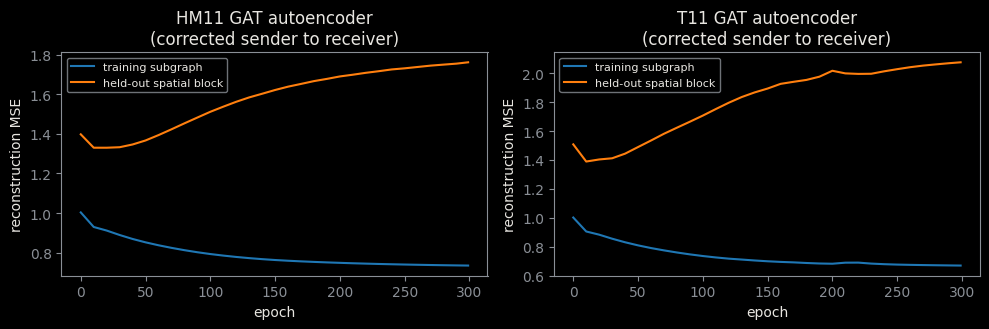

saved model2_gat_reconstruction_corrected.csv


In [22]:
# Model 2: single-seed transductive spatial-block reconstruction
#
# A contiguous spatial block is held out. The autoencoder is trained on the
# training subgraph only (edges whose sender AND receiver are both training
# spots), with PCA and the scaler fitted on training spots only. Reconstruction
# of the held-out block is then evaluated on the full graph.
#
# This is a transductive protocol. The held-out spots belong to the same graph
# and are reconstructed within it, so it is NOT an inductive evaluation and is
# not described as one.
#
# All edges are decoded through sender_receiver(), so the attention is scored on
# (sender, receiver) and messages are aggregated into the receiver.
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def gat_reconstruction(st, hidden=32, heads=4, epochs=300, lr=5e-3,
                       val_frac=0.2, n_pca=50, seed=SEED):
    expr, edges = st["expr"], st["edges"]
    tr, va = spatial_block_split(_coords(st), val_frac, seed)
    trb = np.zeros(len(expr), bool); trb[tr] = True

    pca = PCA(n_components=min(n_pca, expr.shape[1] - 1),
              random_state=seed).fit(expr[tr])                    # train spots only
    feats = pca.transform(expr)
    mu, sd = feats[tr].mean(0), feats[tr].std(0) + 1e-8           # train spots only
    feats = (feats - mu) / sd
    X = torch.tensor(feats, dtype=torch.float32, device=device)

    s_tr, r_tr = train_only_edges(edges, trb)                     # CORRECTED orientation
    s_tr, r_tr = s_tr.to(device), r_tr.to(device)
    s_all, r_all = sender_receiver(edges)                         # CORRECTED orientation
    s_all, r_all = s_all.to(device), r_all.to(device)

    trm = torch.as_tensor(trb, device=device); vam = ~trm

    torch.manual_seed(seed)
    net = GATAutoencoder(X.size(1), hidden, heads).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    tc, vc, xs = [], [], []

    for ep in range(epochs):
        net.train()
        loss = F.mse_loss(net(X, s_tr, r_tr)[trm], X[trm])        # training subgraph
        opt.zero_grad(); loss.backward(); opt.step()
        if ep % 10 == 0 or ep == epochs - 1:
            net.eval()
            with torch.no_grad():
                ptr = net(X, s_tr, r_tr)
                pva = net(X, s_all, r_all)                        # full graph
                tc.append(float(F.mse_loss(ptr[trm], X[trm])))
                vc.append(float(F.mse_loss(pva[vam], X[vam])))
                xs.append(ep)

    with torch.no_grad():
        pn_tr = net(X, s_tr, r_tr).cpu().numpy()
        pn_va = net(X, s_all, r_all).cpu().numpy()
    Xn = X.cpu().numpy()

    return dict(params=sum(pp.numel() for pp in net.parameters()),
                tr=tc, va=vc, xs=xs,
                train_mse=tc[-1], heldout_mse=vc[-1],
                train_r2=r2_score(Xn[tr], pn_tr[tr]),
                heldout_r2=r2_score(Xn[va], pn_va[va]))

gat_rows = []
fig, axes = plt.subplots(1, max(1, len(states)),
                         figsize=(5 * max(1, len(states)), 3.4), squeeze=False)

for axis, (section, st) in zip(axes[0], states.items()):
    m = gat_reconstruction(st)
    relative_gap = ((m["heldout_mse"] - m["train_mse"])
                    / max(abs(m["train_mse"]), 1e-12))

    gat_rows.append({
        "section": section,
        "seed": SEED,
        "protocol": "single-seed transductive spatial-block reconstruction",
        "trainable_parameters": m["params"],
        "train_mse": m["train_mse"],
        "heldout_mse": m["heldout_mse"],
        "train_r2": m["train_r2"],
        "heldout_r2": m["heldout_r2"],
        "relative_mse_gap": relative_gap,
    })

    axis.plot(m["xs"], m["tr"], label="training subgraph")
    axis.plot(m["xs"], m["va"], label="held-out spatial block")
    axis.set_title(f"{section} GAT autoencoder\n(corrected sender to receiver)")
    axis.set_xlabel("epoch"); axis.set_ylabel("reconstruction MSE")
    axis.legend(fontsize=8)

gat_evaluation_df = pd.DataFrame(gat_rows)
print("Model 2: single-seed transductive spatial-block reconstruction")
print(gat_evaluation_df.to_string(index=False))
gat_evaluation_df.to_csv(f"{OUTDIR}/model2_gat_reconstruction_corrected.csv", index=False)
plt.tight_layout(); plt.show()
print("saved model2_gat_reconstruction_corrected.csv")


### Interpretation

For HM11, training \(R^2\) was 0.265 and held-out \(R^2\) was -0.267. For T11, training \(R^2\) was 0.330 and held-out \(R^2\) was -0.381.

The localisation ratios were 0.98 for HM11 and 1.03 for T11. The matched random localisation ratios were also close to one.

The autoencoder did not show positive transfer to the held-out spatial blocks and did not isolate a distinct local-attention response in this experiment.


## 7. Model 3: constrained fibrotic-to-tumour GGAT

We trained a constrained GGAT using fibrotic-programme features as predictors and tumour-programme features as targets.

We used sender-to-receiver graph edges. We compared the attention-weighted tumour response with the uniform response to test whether learned neighbour weights selected a distinct local niche-to-tumour signal.


### Model 3 fitting

The next cell trains the constrained GGAT and compares the attention-weighted and uniform tumour-programme deltas.


In [23]:
GGAT_HIDDEN, GGAT_HEADS, GGAT_EPOCHS, GGAT_LR = 32, 4, 150, 5e-3

class PureTorchGGAT(nn.Module):
    """Constrained GGAT with the sender and receiver roles the right way round."""
    def __init__(self, in_dim, hidden, heads):
        super().__init__(); self.heads = heads
        self.lin = nn.Linear(in_dim, hidden * heads, bias=False)
        self.att_sender = nn.Parameter(torch.randn(heads, hidden) * 0.1)
        self.att_receiver = nn.Parameter(torch.randn(heads, hidden) * 0.1)
        self.out = nn.Linear(hidden * heads, 1); self.leaky = nn.LeakyReLU(0.2)

    def forward(self, x, sender_receiver_pair, return_attention=False):
        N = x.size(0); H = self.heads
        h = self.lin(x).view(N, H, -1)
        sender, receiver = sender_receiver_pair              # already decoded
        e = self.leaky((h[sender] * self.att_sender).sum(-1)
                       + (h[receiver] * self.att_receiver).sum(-1))
        e = e - e.max()
        a = torch.exp(e)
        # softmax over each RECEIVER's incoming edges
        denom = torch.zeros(N, H, device=x.device).index_add_(0, receiver, a) + 1e-12
        alpha = a / denom[receiver]
        # aggregate the SENDER's features INTO the RECEIVER
        agg = torch.zeros(N, H, h.size(-1), device=x.device).index_add_(
            0, receiver, h[sender] * alpha.unsqueeze(-1)).reshape(N, -1)
        pred = self.out(agg).squeeze(-1)
        return (pred, alpha.mean(1).detach()) if return_attention else pred

def make_ggat(in_dim):
    # Use the pure torch implementation so the orientation is explicit and
    # verifiable, rather than relying on an external convention.
    return PureTorchGGAT(in_dim, GGAT_HIDDEN, GGAT_HEADS).to(device)

def train_ggat(expr, edges, fib_idx, tum_idx):
    torch.manual_seed(SEED); np.random.seed(SEED)
    fib = expr[:, fib_idx].mean(1) if len(fib_idx) else np.zeros(expr.shape[0], "float32")
    tum = expr[:, tum_idx].mean(1) if len(tum_idx) else np.zeros(expr.shape[0], "float32")
    Xf = fib.reshape(-1, 1).astype("float32")
    Xf = (Xf - Xf.mean(0)) / (Xf.std(0) + 1e-8)                  # FIBROTIC-ONLY predictor
    x = torch.from_numpy(Xf).to(device)
    y = torch.from_numpy(((tum - tum.mean()) / (tum.std() + 1e-8)).astype("float32")).to(device)

    sender, receiver = sender_receiver(edges)                    # CORRECTED orientation
    pair = (sender.to(device), receiver.to(device))

    model = make_ggat(x.size(1))
    opt = torch.optim.Adam(model.parameters(), lr=GGAT_LR, weight_decay=1e-4)
    for _ in range(GGAT_EPOCHS):
        opt.zero_grad(); loss = F.mse_loss(model(x, pair), y)
        loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred, alpha = model(x, pair, return_attention=True)
        ss_res = ((pred - y) ** 2).sum().item()
        ss_tot = ((y - y.mean()) ** 2).sum().item() + 1e-12
    return alpha.cpu().numpy(), float(1 - ss_res / ss_tot)

def niche_specific_attention(alpha, edges, cc_values, src_cc, tum_mask):
    """Attention flowing FROM the niche INTO tumour spots.

    This is the correction that matters most for the biology. Previously the
    edge tensor was unpacked as (s, d) = (edges[0], edges[1]), which is
    (receiver, sender), so the mask
        (cc_values[s] == src_cc) & tum_mask[d]
    was actually selecting edges where the TUMOUR sends into the NICHE, the
    opposite of what the analysis claims to measure.

    Decoding to (sender, receiver) makes the mask select what it is supposed to:
    the sender lies in the niche, and the receiver is a tumour spot.
    """
    sender, receiver = sender_receiver(edges)
    s = sender.numpy(); r = receiver.numpy()
    N = len(cc_values)
    emask = (cc_values[s] == src_cc) & tum_mask[r]      # niche SENDS, tumour RECEIVES
    recv = np.zeros(N)
    if emask.any():
        np.add.at(recv, r[emask], alpha[emask])         # accumulate into the RECEIVER
    return recv

def attention_weighted_delta(d_spot, niche_attn, tum_mask):
    w = niche_attn * tum_mask
    if w.sum() <= 0:
        return float(d_spot[tum_mask].mean()) if tum_mask.any() else 0.0
    w = w / w.sum()
    return float((d_spot * w).sum())

ggat_rows = []
for nm, st in states.items():
    best, pack, _, _ = strongest[nm]
    if pack is None:
        continue
    src_rows, sub, gidx = pack
    fib_idx, tum_idx = st["fib_genes"], st["tum_genes"]

    print(f"\n--- {nm}: constrained GGAT (fibrotic-only), niche {best} ---")
    alpha, r2 = train_ggat(st["expr"], st["edges"], fib_idx, tum_idx)
    print(f"  fibrotic to tumour GGAT fit R^2 = {r2:.3f}")

    n_attn = niche_specific_attention(alpha, st["edges"], st["cc"], best, st["tum_spots"])
    cf = relax(st["model"],
               initial_programme_downscaling(st["expr"], gidx, src_rows),
               st["edges"], st["n"])
    d_spot = (cf - st["base"])[:, tum_idx].mean(1)

    uni = float(d_spot[st["tum_spots"]].mean())
    att = attention_weighted_delta(d_spot, n_attn, st["tum_spots"])
    n_wired = int(((n_attn > 0) & st["tum_spots"]).sum())

    print(f"  uniform tumour delta = {uni:+.6f}")
    print(f"  niche-attention tumour delta = {att:+.6f}")
    print(f"  tumour spots RECEIVING from the niche = {n_wired}")

    ggat_rows.append({"section": nm, "seed": SEED, "niche": best,
                      "ggat_r2": round(r2, 3),
                      "uniform_delta": round(uni, 6),
                      "attention_delta": round(att, 6),
                      "tumour_spots_receiving_from_niche": n_wired})

ggat_evaluation_df = pd.DataFrame(ggat_rows)
print("")
print("Model 3: constrained GGAT, corrected sender to receiver orientation")
print(ggat_evaluation_df.to_string(index=False))
ggat_evaluation_df.to_csv(f"{OUTDIR}/model3_ggat_corrected.csv", index=False)
print("saved model3_ggat_corrected.csv")



--- HM11: constrained GGAT (fibrotic-only), niche CC4 ---
  fibrotic to tumour GGAT fit R^2 = 0.148
  uniform tumour delta = -0.000960
  niche-attention tumour delta = -0.000890
  tumour spots RECEIVING from the niche = 122

--- T11: constrained GGAT (fibrotic-only), niche CC5 ---
  fibrotic to tumour GGAT fit R^2 = 0.479
  uniform tumour delta = -0.001651
  niche-attention tumour delta = -0.001673
  tumour spots RECEIVING from the niche = 12

Model 3: constrained GGAT, corrected sender to receiver orientation
section  seed niche  ggat_r2  uniform_delta  attention_delta  tumour_spots_receiving_from_niche
   HM11     0   CC4    0.148      -0.000960        -0.000890                                122
    T11     0   CC5    0.479      -0.001651        -0.001673                                 12
saved model3_ggat_corrected.csv


### Spatial hold-out evaluation

We standardised the fibrotic predictors and tumour targets using training spots. We fitted the model on the training subgraph and evaluated it on a contiguous held-out region.

The reported \(R^2\) values describe predictive transfer. They do not identify causal direction.


### Model 3 evaluation

The next cell calculates the single-seed spatial-block reconstruction metrics and saves the results and figure.


Model 3: single-seed transductive spatial-block reconstruction
section  seed                                              protocol  trainable_parameters  train_mse  heldout_mse  train_r2  heldout_r2  relative_mse_gap
   HM11     0 single-seed transductive spatial-block reconstruction                   513   0.811040     1.513610  0.188959   -0.377766          0.866257
    T11     0 single-seed transductive spatial-block reconstruction                   513   0.650099     0.739787  0.349901   -0.097301          0.137960


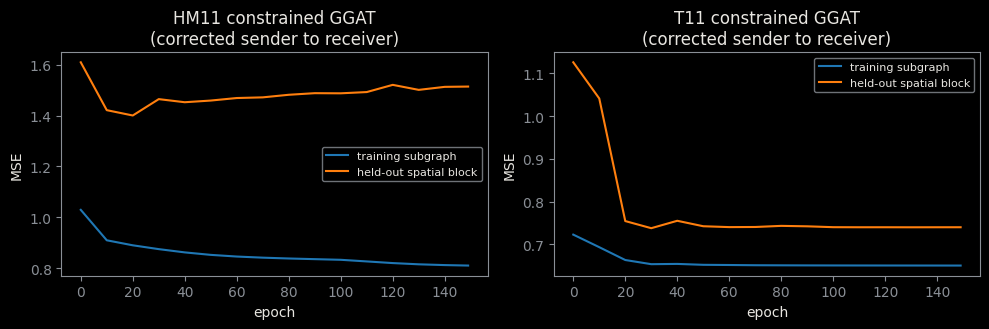

saved model3_ggat_reconstruction_corrected.csv


In [24]:
# Model 3: single-seed transductive spatial-block reconstruction
#
# A contiguous spatial block is held out. The constrained GGAT is fitted on the
# training subgraph only (edges whose sender AND receiver are both training
# spots), with the normalisation statistics computed on training spots only. The
# held-out block is then reconstructed on the full graph.
#
# This is a transductive protocol. The held-out spots belong to the same graph
# and are reconstructed within it, so it is NOT an inductive evaluation and is
# not described as one.
#
# The edge tensor is decoded through sender_receiver(), so attention is scored on
# (sender, receiver) and messages are aggregated into the receiver.
def ggat_reconstruction(st, epochs=150, lr=5e-3, val_frac=0.2, seed=SEED):
    expr, edges = st["expr"], st["edges"]
    fib_idx, tum_idx = st["fib_genes"], st["tum_genes"]
    tr, va = spatial_block_split(_coords(st), val_frac, seed)

    fibs = expr[:, fib_idx].mean(1) if len(fib_idx) else np.zeros(len(expr), "float32")
    tums = expr[:, tum_idx].mean(1) if len(tum_idx) else np.zeros(len(expr), "float32")
    fmu, fsd = fibs[tr].mean(), fibs[tr].std() + 1e-8          # train spots only
    tmu, tsd = tums[tr].mean(), tums[tr].std() + 1e-8          # train spots only
    Xf = ((fibs - fmu) / fsd).reshape(-1, 1).astype("float32")
    y = ((tums - tmu) / tsd).astype("float32")

    x = torch.from_numpy(Xf).to(device)
    yt = torch.from_numpy(y).to(device)
    trb = np.zeros(len(y), bool); trb[tr] = True

    s_tr, r_tr = train_only_edges(edges, trb)                  # CORRECTED orientation
    pair_tr = (s_tr.to(device), r_tr.to(device))
    s_all, r_all = sender_receiver(edges)                      # CORRECTED orientation
    pair_all = (s_all.to(device), r_all.to(device))

    trm = torch.as_tensor(trb, device=device); vam = ~trm

    torch.manual_seed(seed)
    model = make_ggat(x.size(1))
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    tc, vc, xs = [], [], []

    for ep in range(epochs):
        model.train()
        loss = F.mse_loss(model(x, pair_tr)[trm], yt[trm])     # training subgraph
        opt.zero_grad(); loss.backward(); opt.step()
        if ep % 10 == 0 or ep == epochs - 1:
            model.eval()
            with torch.no_grad():
                ptr = model(x, pair_tr)
                pva = model(x, pair_all)                       # full graph
                tc.append(float(F.mse_loss(ptr[trm], yt[trm])))
                vc.append(float(F.mse_loss(pva[vam], yt[vam])))
                xs.append(ep)

    with torch.no_grad():
        pn_tr = model(x, pair_tr).cpu().numpy()
        pn_va = model(x, pair_all).cpu().numpy()

    return dict(params=sum(pp.numel() for pp in model.parameters()),
                tr=tc, va=vc, xs=xs,
                train_mse=tc[-1], heldout_mse=vc[-1],
                train_r2=r2_score(y[tr], pn_tr[tr]),
                heldout_r2=r2_score(y[va], pn_va[va]))

ggat_recon_rows = []
fig, axes = plt.subplots(1, max(1, len(states)),
                         figsize=(5 * max(1, len(states)), 3.4), squeeze=False)

for axis, (section, st) in zip(axes[0], states.items()):
    m = ggat_reconstruction(st)
    relative_gap = ((m["heldout_mse"] - m["train_mse"])
                    / max(abs(m["train_mse"]), 1e-12))

    ggat_recon_rows.append({
        "section": section,
        "seed": SEED,
        "protocol": "single-seed transductive spatial-block reconstruction",
        "trainable_parameters": m["params"],
        "train_mse": m["train_mse"],
        "heldout_mse": m["heldout_mse"],
        "train_r2": m["train_r2"],
        "heldout_r2": m["heldout_r2"],
        "relative_mse_gap": relative_gap,
    })

    axis.plot(m["xs"], m["tr"], label="training subgraph")
    axis.plot(m["xs"], m["va"], label="held-out spatial block")
    axis.set_title(f"{section} constrained GGAT\n(corrected sender to receiver)")
    axis.set_xlabel("epoch"); axis.set_ylabel("MSE")
    axis.legend(fontsize=8)

ggat_reconstruction_df = pd.DataFrame(ggat_recon_rows)
print("Model 3: single-seed transductive spatial-block reconstruction")
print(ggat_reconstruction_df.to_string(index=False))
ggat_reconstruction_df.to_csv(f"{OUTDIR}/model3_ggat_reconstruction_corrected.csv", index=False)
plt.tight_layout(); plt.show()
print("saved model3_ggat_reconstruction_corrected.csv")


### Interpretation

For HM11, training \(R^2\) was 0.189 and held-out \(R^2\) was -0.378. The uniform and attention-weighted tumour deltas were -0.000960 and -0.000890.

For T11, training \(R^2\) was 0.350 and held-out \(R^2\) was -0.097. The uniform and attention-weighted tumour deltas were -0.001651 and -0.001673.

The constrained GGAT did not show positive held-out transfer. Its attention-weighted responses were close to the uniform responses, so the analysis did not isolate a distinct local response.


## 8. Model 4: constant-row-mass stochastic attention

We used a receiver-row graph with \(K=6\) sending neighbours for each receiver.

The uniform operator assigns weight one to every neighbour. The attention operator applies a row softmax and multiplies the probabilities by six. Both operators therefore have total receiver-row mass \(K=6\).

We used this design to compare learned attention with uniform aggregation on the same graph and aggregation scale. Constant row mass verifies the implemented constraint. It does not prove that the original Celcomen identifiability result extends to learned, data-dependent attention.

This analysis uses one seed and is interpreted as exploratory.


In [25]:
from __future__ import annotations

import math
import os
import random
from collections import deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.sparse import issparse
from sklearn.neighbors import kneighbors_graph

SEED = 0
K = 6
ATTENTION_DIM = 32

EPOCHS = 200
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4
ZMFT_SCALAR = 1e-1
KEEP_FRACTION = 0.15

RUN_SPATIAL_HOLDOUT = True
HOLDOUT_FRACTION = 0.20
HOLDOUT_EPOCHS = 120

N_PERMUTATIONS = 2000

RUN_PROGRAMME_DOWNSCALING = True
RELAXATION_STEPS = 80
RELAXATION_LR = 1e-3
INITIAL_DOWNSCALING_FACTOR = 0.0

APPLY_CPM_LOG1P = True
CPM_TARGET = 1e6

ECOTYPE_COLUMN = "CompositionCluster_CC"
THEME_COLUMN = "theme"
FIBROTIC_THEMES = {"fibrotic"}
TUMOUR_THEMES = {"tumour/metabolic", "tumour_metabolic", "tumour", "tumor"}

SECTION_FILES = {
    "HM11": {
        "h5ad": "handoff_to_eva/data/IU_PDA_HM11.h5ad",
        "drivers": "handoff_to_eva/drivers/HM11_drivers_per_CC.csv",
        "label": "metastasis",
    },
    "T11": {
        "h5ad": "handoff_to_eva/data/IU_PDA_T11.h5ad",
        "drivers": "handoff_to_eva/drivers/T11_drivers_per_CC.csv",
        "label": "primary",
    },
}

OUTPUT_DIRECTORY = Path(OUTDIR) / "model4_constant_mass_attention"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Seed:", SEED)
print("K:", K)
print("Output:", OUTPUT_DIRECTORY.resolve())
print(
    "Preprocessing:",
    f"CPM({CPM_TARGET:g}) + log1p + row-L2"
    if APPLY_CPM_LOG1P
    else "input X + row-L2",
)

Device: cuda
Seed: 0
K: 6
Output: /content/celcomen_complete_3seed_outputs/model4_constant_mass_attention
Preprocessing: CPM(1e+06) + log1p + row-L2


### Data and graph audit

We reloaded HM11 and T11 using CPM scaling, log transformation, and per-spot L2 normalisation.

We constructed an explicit receiver-row KNN graph with six sending neighbours for every receiving spot. This defined the edge direction and aggregation mass used by Model 4.


In [26]:
def find_file(relative_path):
    requested = Path(relative_path)
    for candidate in (requested, Path.cwd() / requested, Path("/content") / requested):
        if candidate.exists():
            return candidate.resolve()

    matches = sorted(
        Path.cwd().glob(f"**/{requested.name}"),
        key=lambda path: (len(path.parts), str(path)),
    )
    if not matches:
        raise FileNotFoundError(
            f"Could not locate {relative_path}. Place handoff_to_eva next to the notebook."
        )
    if len(matches) > 1:
        print(f"Warning: multiple matches for {requested.name}; using {matches[0]}")
    return matches[0].resolve()


def dense_float32(matrix):
    if issparse(matrix):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def row_l2(matrix):
    matrix = np.asarray(matrix, dtype=np.float32)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return matrix / norms


def canonical(value):
    return str(value).strip().lower()


def identify_driver_columns(frame):
    lower = {column.lower(): column for column in frame.columns}
    columns = {
        "gene": lower.get("gene"),
        "role": lower.get("role"),
        "theme": lower.get("theme"),
        "cc": (
            lower.get("cc")
            or lower.get("compositioncluster_cc")
            or lower.get("composition_cluster_cc")
        ),
    }
    missing = [name for name, column in columns.items() if column is None]
    if missing:
        raise ValueError(f"Driver table is missing: {missing}")
    return columns


def dominant_programme(drivers, columns):
    selected = drivers[
        drivers[columns["role"]].astype(str).str.lower().eq("perturb_target")
    ].copy()
    selected[columns["gene"]] = selected[columns["gene"]].astype(str).str.upper()
    selected[columns["theme"]] = selected[columns["theme"]].map(canonical)

    mapping = {}
    for gene, subset in selected.groupby(columns["gene"]):
        theme = subset[columns["theme"]].value_counts().index[0]
        if theme in FIBROTIC_THEMES:
            mapping[gene] = "fibrotic"
        elif theme in TUMOUR_THEMES:
            mapping[gene] = "tumour"
    return mapping


def load_section(section, specification):
    h5ad_path = find_file(specification["h5ad"])
    drivers_path = find_file(specification["drivers"])

    adata = sc.read_h5ad(h5ad_path)
    if ECOTYPE_COLUMN not in adata.obs or THEME_COLUMN not in adata.obs:
        raise ValueError(f"{section}: required spot annotations are missing")
    if "spatial" not in adata.obsm:
        raise ValueError(f"{section}: adata.obsm['spatial'] is missing")

    analysis_adata = adata.copy()
    if APPLY_CPM_LOG1P:
        sc.pp.normalize_total(analysis_adata, target_sum=CPM_TARGET)
        sc.pp.log1p(analysis_adata)

    expression = row_l2(dense_float32(analysis_adata.X))
    coordinates = np.asarray(analysis_adata.obsm["spatial"], dtype=np.float64)

    drivers = pd.read_csv(drivers_path)
    columns = identify_driver_columns(drivers)
    programme = dominant_programme(drivers, columns)

    genes = [str(gene) for gene in analysis_adata.var_names]
    genes_upper = [gene.upper() for gene in genes]
    gene_to_index = {gene: index for index, gene in enumerate(genes_upper)}

    fibrotic_genes = [
        index for index, gene in enumerate(genes_upper)
        if programme.get(gene) == "fibrotic"
    ]
    tumour_genes = [
        index for index, gene in enumerate(genes_upper)
        if programme.get(gene) == "tumour"
    ]
    if not fibrotic_genes or not tumour_genes:
        raise ValueError(
            f"{section}: empty programme set "
            f"(fibrotic={len(fibrotic_genes)}, tumour={len(tumour_genes)})"
        )

    themes = analysis_adata.obs[THEME_COLUMN].astype(str).map(canonical).to_numpy()

    return {
        "section": section,
        "label": specification["label"],
        "expression": expression,
        "coordinates": coordinates,
        "genes": genes,
        "genes_upper": genes_upper,
        "gene_to_index": gene_to_index,
        "drivers": drivers,
        "driver_columns": columns,
        "fibrotic_genes": fibrotic_genes,
        "tumour_genes": tumour_genes,
        "fibrotic_spots": np.isin(themes, list(FIBROTIC_THEMES)),
        "tumour_spots": np.isin(themes, list(TUMOUR_THEMES)),
        "cc_values": analysis_adata.obs[ECOTYPE_COLUMN].astype(str).to_numpy(),
    }


sections = {
    section: load_section(section, specification)
    for section, specification in SECTION_FILES.items()
}

for section, data in sections.items():
    print(
        f"{section}: expression={data['expression'].shape}, "
        f"fibrotic genes={len(data['fibrotic_genes'])}, "
        f"tumour genes={len(data['tumour_genes'])}"
    )

HM11: expression=(3921, 117), fibrotic genes=26, tumour genes=29
T11: expression=(2768, 117), fibrotic genes=91, tumour genes=26


In [27]:
@dataclass(frozen=True)
class GraphSupport:
    sender: torch.Tensor
    receiver: torch.Tensor
    n_spots: int
    k: int


def receiver_knn_support(coordinates, k, device):
    coordinates = np.asarray(coordinates, dtype=np.float64)
    n_spots = coordinates.shape[0]
    effective_k = min(int(k), n_spots - 1)
    if effective_k < 1:
        raise ValueError("At least two spots are required")

    graph = kneighbors_graph(
        coordinates,
        n_neighbors=effective_k,
        mode="connectivity",
        include_self=False,
    )
    receiver, sender = graph.nonzero()
    order = np.lexsort((sender, receiver))
    receiver, sender = receiver[order], sender[order]

    counts = np.bincount(receiver, minlength=n_spots)
    if not np.all(counts == effective_k):
        raise RuntimeError("Each receiver must have exactly K senders")

    return GraphSupport(
        sender=torch.as_tensor(sender, dtype=torch.long, device=device),
        receiver=torch.as_tensor(receiver, dtype=torch.long, device=device),
        n_spots=n_spots,
        k=effective_k,
    )


supports = {
    section: receiver_knn_support(data["coordinates"], K, DEVICE)
    for section, data in sections.items()
}

for section, support in supports.items():
    print(
        f"{section}: {support.n_spots:,} receivers, "
        f"{support.sender.numel():,} edges, K={support.k}"
    )

HM11: 3,921 receivers, 23,526 edges, K=6
T11: 2,768 receivers, 16,608 edges, K=6


### Constant-mass implementation and synthetic audit

The uniform and attention operators used the same total receiver-row mass.

We tested the row mass, sparse-versus-dense aggregation equivalence, finite gradients, and the complete trainable-parameter count before fitting the tissue data.


In [28]:
def segmented_softmax(scores, groups, n_groups):
    maxima = torch.full(
        (n_groups,),
        -torch.inf,
        dtype=scores.dtype,
        device=scores.device,
    )
    if hasattr(maxima, "scatter_reduce_"):
        maxima.scatter_reduce_(0, groups, scores, reduce="amax", include_self=True)
    else:
        for group in range(n_groups):
            values = scores[groups == group]
            if values.numel():
                maxima[group] = values.max()

    exponentials = torch.exp(scores - maxima[groups])
    denominators = torch.zeros(
        n_groups,
        dtype=scores.dtype,
        device=scores.device,
    ).index_add_(0, groups, exponentials)

    return exponentials / denominators[groups].clamp_min(
        torch.finfo(scores.dtype).tiny
    )


def initial_symmetric(n_genes, seed, scale=0.05):
    generator = torch.Generator(device="cpu").manual_seed(seed)
    matrix = torch.empty(n_genes, n_genes).uniform_(
        -scale, scale, generator=generator
    )
    matrix = (matrix + matrix.T) / 2
    matrix.fill_diagonal_(1.0)
    return matrix


class ConstantMassCelcomen(nn.Module):
    def __init__(self, n_genes, k, mode, attention_dim=32, seed=0):
        super().__init__()
        if mode not in {"uniform", "attention"}:
            raise ValueError("mode must be uniform or attention")

        self.n_genes = int(n_genes)
        self.k = int(k)
        self.mode = mode
        self.attention_dim = int(attention_dim)

        self.W = nn.Parameter(initial_symmetric(n_genes, seed))
        self.U = nn.Parameter(initial_symmetric(n_genes, seed + 1))

        if mode == "attention":
            self.query = nn.Linear(n_genes, attention_dim, bias=False)
            self.key = nn.Linear(n_genes, attention_dim, bias=False)
            q_generator = torch.Generator(device="cpu").manual_seed(seed + 101)
            k_generator = torch.Generator(device="cpu").manual_seed(seed + 102)
            with torch.no_grad():
                self.query.weight.copy_(
                    0.02 * torch.randn(self.query.weight.shape, generator=q_generator)
                )
                self.key.weight.copy_(
                    0.02 * torch.randn(self.key.weight.shape, generator=k_generator)
                )

    def edge_mass(self, expression, support):
        if self.mode == "uniform":
            return torch.ones(
                support.sender.numel(),
                dtype=expression.dtype,
                device=expression.device,
            )

        query = self.query(expression)
        key = self.key(expression)
        scores = (
            query[support.receiver] * key[support.sender]
        ).sum(dim=1) / math.sqrt(self.attention_dim)

        probabilities = segmented_softmax(
            scores, support.receiver, support.n_spots
        )
        return support.k * probabilities

    def messages(self, expression, support):
        mass = self.edge_mass(expression, support)
        neighbours = torch.zeros_like(expression)
        neighbours.index_add_(
            0,
            support.receiver,
            expression[support.sender] * mass[:, None],
        )
        inter_message = F.linear(neighbours, self.W)
        intra_message = F.linear(expression, self.U)
        return inter_message, intra_message, mass

    @staticmethod
    def log_two_sinh_over_g(g):
        value = float(g.detach().cpu())
        if value < 1e-4:
            return (
                torch.as_tensor(math.log(2.0), dtype=g.dtype, device=g.device)
                + g.square() / 6.0
            )
        if value > 20.0:
            return g - torch.log(g)
        return torch.log(2.0 * torch.sinh(g) / g)

    def log_z_mft(self, expression):
        n_spots = expression.shape[0]
        mean_gene = expression.mean(dim=0, keepdim=True).T
        g = torch.linalg.vector_norm(
            (self.k * self.W + 2.0 * self.U) @ mean_gene
        )
        z_mean = -n_spots * (
            mean_gene.T
            @ (self.U + 0.5 * self.k * self.W)
            @ mean_gene
        ).squeeze()
        return z_mean + n_spots * self.log_two_sinh_over_g(g)

    def objective(self, expression, support, zmft_scalar):
        inter_message, intra_message, mass = self.messages(expression, support)
        log_z = self.log_z_mft(expression)
        loss = (
            log_z
            - zmft_scalar * (inter_message * expression).sum()
            - zmft_scalar * (intra_message * expression).sum()
        )
        return loss, {
            "log_z": log_z,
            "inter_message": inter_message,
            "intra_message": intra_message,
            "mass": mass,
        }


@torch.no_grad()
def project_matrix_(parameter, keep_fraction):
    if not (0 < keep_fraction <= 1):
        raise ValueError("keep_fraction must be in (0, 1]")

    matrix = torch.clamp(
        (parameter.data + parameter.data.T) / 2,
        -1.0,
        1.0,
    )
    n_genes = matrix.shape[0]
    upper = torch.triu_indices(n_genes, n_genes, offset=1, device=matrix.device)
    values = matrix[upper[0], upper[1]].abs()
    n_keep = max(1, int(round(keep_fraction * values.numel())))
    selected = torch.topk(values, k=n_keep, largest=True, sorted=False).indices

    mask = torch.zeros_like(matrix, dtype=torch.bool)
    rows, columns = upper[0][selected], upper[1][selected]
    mask[rows, columns] = True
    mask[columns, rows] = True
    diagonal = torch.arange(n_genes, device=matrix.device)
    mask[diagonal, diagonal] = True

    matrix = torch.where(mask, matrix, torch.zeros_like(matrix))
    matrix[diagonal, diagonal] = 1.0
    parameter.data.copy_(matrix)


@torch.no_grad()
def project_model_(model):
    project_matrix_(model.W, KEEP_FRACTION)
    project_matrix_(model.U, KEEP_FRACTION)


def trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def active_unique_edges(matrix):
    array = matrix.detach().cpu().numpy()
    return int(np.triu(np.abs(array) > 1e-12, k=1).sum())

In [29]:
def synthetic_audit():
    set_seed(SEED)
    n_spots, n_genes = 48, 9
    coordinates = np.random.RandomState(SEED).normal(size=(n_spots, 2))
    expression = row_l2(
        np.random.RandomState(SEED + 1).normal(size=(n_spots, n_genes))
    )
    support = receiver_knn_support(coordinates, K, torch.device("cpu"))
    x = torch.from_numpy(expression)

    audit_rows = []
    for mode in ("uniform", "attention"):
        model = ConstantMassCelcomen(
            n_genes, support.k, mode, ATTENTION_DIM, SEED
        )
        loss, diagnostics = model.objective(x, support, ZMFT_SCALAR)
        row_mass = torch.zeros(n_spots).index_add_(
            0, support.receiver.cpu(), diagnostics["mass"].detach().cpu()
        )
        loss.backward()

        audit_rows.append({
            "model": mode,
            "row_mass_min": float(row_mass.min()),
            "row_mass_max": float(row_mass.max()),
            "row_mass_std": float(row_mass.std()),
            "trainable_parameters": trainable_parameters(model),
            "all_gradients_finite": all(
                parameter.grad is not None
                and torch.isfinite(parameter.grad).all()
                for parameter in model.parameters()
                if parameter.requires_grad
            ),
        })

    dense_adjacency = torch.zeros(n_spots, n_spots)
    dense_adjacency[support.receiver.cpu(), support.sender.cpu()] = 1.0
    sparse_neighbours = torch.zeros_like(x).index_add_(
        0, support.receiver.cpu(), x[support.sender.cpu()]
    )
    if not torch.allclose(sparse_neighbours, dense_adjacency @ x, atol=1e-6):
        raise AssertionError("Sparse aggregation does not equal dense A @ X")

    audit = pd.DataFrame(audit_rows)
    if not np.allclose(audit["row_mass_min"], support.k, atol=1e-5):
        raise AssertionError("Minimum row mass is not K")
    if not np.allclose(audit["row_mass_max"], support.k, atol=1e-5):
        raise AssertionError("Maximum row mass is not K")

    print(audit.to_string(index=False))
    print("Synthetic implementation audit passed.")
    return audit


synthetic_audit_df = synthetic_audit()

    model  row_mass_min  row_mass_max  row_mass_std  trainable_parameters  all_gradients_finite
  uniform      6.000000           6.0  0.000000e+00                   162                  True
attention      5.999999           6.0  3.110543e-07                   738                  True
Synthetic implementation audit passed.


### Matched one-seed training

The uniform and attention models started from the same coupling initialisation. They used the same objective, optimiser, graph support, and sparsity projection.

We counted all trainable parameters. Training objective values were treated as descriptive because the attention model contains additional query and key parameters.



Training HM11, seed=0

Training T11, seed=0
section     model  seed  trainable_parameters  active_unique_W_edges  active_unique_U_edges  final_loss_per_spot
   HM11   uniform     0                 27378                   1018                   1018            -0.652355
   HM11 attention     0                 34866                   1018                   1018            -0.694190
    T11   uniform     0                 27378                   1018                   1018            -0.544391
    T11 attention     0                 34866                   1018                   1018            -0.602479


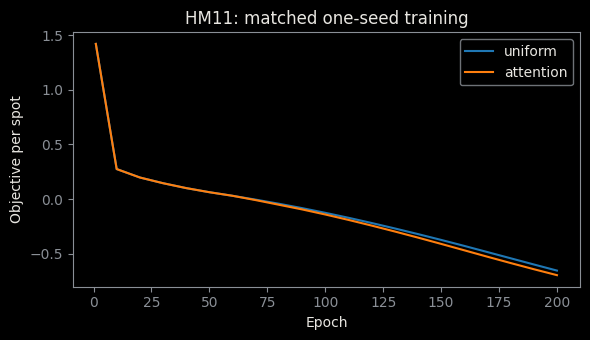

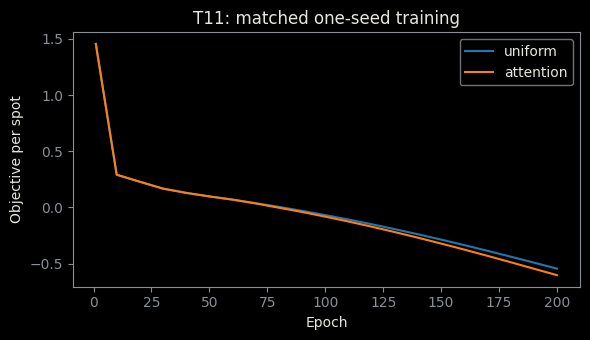

In [30]:
def fit_model(expression, support, mode, epochs, seed=SEED):
    set_seed(seed)
    x = torch.as_tensor(expression, dtype=torch.float32, device=DEVICE)
    model = ConstantMassCelcomen(
        n_genes=x.shape[1],
        k=support.k,
        mode=mode,
        attention_dim=ATTENTION_DIM,
        seed=seed,
    ).to(DEVICE)
    project_model_(model)

    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = []
    for epoch in range(epochs):
        model.train()
        optimiser.zero_grad(set_to_none=True)
        loss, diagnostics = model.objective(x, support, ZMFT_SCALAR)
        loss_per_spot = loss / x.shape[0]
        if not torch.isfinite(loss_per_spot):
            raise FloatingPointError(f"{mode}: non-finite loss at epoch {epoch}")
        loss_per_spot.backward()
        optimiser.step()
        project_model_(model)

        if epoch == 0 or (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            history.append({
                "epoch": epoch + 1,
                "loss_per_spot": float(loss_per_spot.detach().cpu()),
                "log_z_per_spot": float(
                    diagnostics["log_z"].detach().cpu() / x.shape[0]
                ),
            })

    return model, pd.DataFrame(history)


full_models = {}
history_frames = []
training_rows = []

for section, data in sections.items():
    print(f"\nTraining {section}, seed={SEED}")
    full_models[section] = {}

    for mode in ("uniform", "attention"):
        model, history = fit_model(
            data["expression"], supports[section], mode, EPOCHS, SEED
        )
        full_models[section][mode] = model
        history_frames.append(history.assign(section=section, model=mode))
        training_rows.append({
            "section": section,
            "model": mode,
            "seed": SEED,
            "trainable_parameters": trainable_parameters(model),
            "active_unique_W_edges": active_unique_edges(model.W),
            "active_unique_U_edges": active_unique_edges(model.U),
            "final_loss_per_spot": float(history["loss_per_spot"].iloc[-1]),
        })

training_history_df = pd.concat(history_frames, ignore_index=True)
training_summary_df = pd.DataFrame(training_rows)
training_history_df.to_csv(OUTPUT_DIRECTORY / "training_history.csv", index=False)
training_summary_df.to_csv(OUTPUT_DIRECTORY / "training_summary.csv", index=False)

print(training_summary_df.to_string(index=False))

for section in sections:
    figure, axis = plt.subplots(figsize=(6, 3.5))
    subset = training_history_df[training_history_df["section"].eq(section)]
    for mode in ("uniform", "attention"):
        curve = subset[subset["model"].eq(mode)]
        axis.plot(curve["epoch"], curve["loss_per_spot"], label=mode)
    axis.set_title(f"{section}: matched one-seed training")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Objective per spot")
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        OUTPUT_DIRECTORY / f"{section}_training_curve.png",
        dpi=150,
    )
    plt.show()

### Row-mass and parameter audit

The receiver-row mass was numerically equal to six in HM11 and T11. The column masses varied, so the attention matrix was not doubly stochastic.

The attention model contained 34,866 trainable parameters. The uniform control contained 27,378.


In [31]:
@torch.no_grad()
def graph_audit(model, expression, support):
    x = torch.as_tensor(expression, dtype=torch.float32, device=DEVICE)
    mass = model.edge_mass(x, support)
    row_mass = torch.zeros(
        support.n_spots, dtype=mass.dtype, device=DEVICE
    ).index_add_(0, support.receiver, mass)
    column_mass = torch.zeros(
        support.n_spots, dtype=mass.dtype, device=DEVICE
    ).index_add_(0, support.sender, mass)
    return {
        "row_mass_min": float(row_mass.min().cpu()),
        "row_mass_max": float(row_mass.max().cpu()),
        "row_mass_std": float(row_mass.std().cpu()),
        "column_mass_mean": float(column_mass.mean().cpu()),
        "column_mass_std": float(column_mass.std().cpu()),
    }


audit_rows = []
for section, models in full_models.items():
    for mode, model in models.items():
        values = graph_audit(model, sections[section]["expression"], supports[section])
        audit_rows.append({
            "section": section,
            "model": mode,
            "seed": SEED,
            **values,
            "trainable_parameters": trainable_parameters(model),
            "statement": (
                "constant row mass; not doubly stochastic"
                if mode == "attention"
                else "constant uniform row mass"
            ),
        })

graph_audit_df = pd.DataFrame(audit_rows)
graph_audit_df.to_csv(
    OUTPUT_DIRECTORY / "graph_mass_and_parameter_audit.csv",
    index=False,
)
print(graph_audit_df.to_string(index=False))

if not np.allclose(graph_audit_df["row_mass_min"], K, atol=1e-4):
    raise AssertionError("At least one minimum row mass differs from K")
if not np.allclose(graph_audit_df["row_mass_max"], K, atol=1e-4):
    raise AssertionError("At least one maximum row mass differs from K")

section     model  seed  row_mass_min  row_mass_max  row_mass_std  column_mass_mean  column_mass_std  trainable_parameters                                statement
   HM11   uniform     0      6.000000      6.000000  0.000000e+00               6.0         0.820652                 27378                constant uniform row mass
   HM11 attention     0      5.999999      6.000001  3.737017e-07               6.0         5.729902                 34866 constant row mass; not doubly stochastic
    T11   uniform     0      6.000000      6.000000  0.000000e+00               6.0         0.930936                 27378                constant uniform row mass
    T11 attention     0      5.999999      6.000001  3.585707e-07               6.0         5.467162                 34866 constant row mass; not doubly stochastic


### Spatially held-out objective

We withheld a contiguous spatial slab and refitted the uniform and attention models using the training region.

We reported the Celcomen-style objective per spot for the training and held-out regions. This measures transfer of the fitted objective. It is not a calibrated expression-reconstruction \(R^2\).


In [32]:
def spatial_block_split(coordinates, fraction, seed):
    coordinates = np.asarray(coordinates, dtype=np.float64)
    rng = np.random.RandomState(seed)
    angle = rng.uniform(0.0, np.pi)
    direction = np.array([np.cos(angle), np.sin(angle)])
    projection = coordinates @ direction
    threshold = np.quantile(projection, 1.0 - fraction)
    train = np.where(projection < threshold)[0]
    heldout = np.where(projection >= threshold)[0]
    if len(train) <= K or len(heldout) <= K:
        raise ValueError("Spatial split is too small for K")
    return train, heldout


@torch.no_grad()
def evaluate(model, expression, support):
    model.eval()
    x = torch.as_tensor(expression, dtype=torch.float32, device=DEVICE)
    loss, _ = model.objective(x, support, ZMFT_SCALAR)
    return {"objective_per_spot": float((loss / x.shape[0]).cpu())}


holdout_rows = []
if RUN_SPATIAL_HOLDOUT:
    for section, data in sections.items():
        train_indices, heldout_indices = spatial_block_split(
            data["coordinates"], HOLDOUT_FRACTION, SEED
        )
        train_expression = data["expression"][train_indices]
        heldout_expression = data["expression"][heldout_indices]
        train_support = receiver_knn_support(
            data["coordinates"][train_indices], K, DEVICE
        )
        heldout_support = receiver_knn_support(
            data["coordinates"][heldout_indices], K, DEVICE
        )

        for mode in ("uniform", "attention"):
            model, _ = fit_model(
                train_expression,
                train_support,
                mode,
                HOLDOUT_EPOCHS,
                SEED,
            )
            train_metrics = evaluate(model, train_expression, train_support)
            heldout_metrics = evaluate(model, heldout_expression, heldout_support)

            holdout_rows.append({
                "section": section,
                "model": mode,
                "seed": SEED,
                "n_train_spots": len(train_indices),
                "n_heldout_spots": len(heldout_indices),
                "trainable_parameters": trainable_parameters(model),
                "train_objective_per_spot": train_metrics["objective_per_spot"],
                "heldout_objective_per_spot": heldout_metrics["objective_per_spot"],
                "objective_gap": (
                    heldout_metrics["objective_per_spot"]
                    - train_metrics["objective_per_spot"]
                ),
            })

holdout_df = pd.DataFrame(holdout_rows)
if not holdout_df.empty:
    holdout_df.to_csv(
        OUTPUT_DIRECTORY / "spatial_holdout_summary.csv",
        index=False,
    )
    print(holdout_df.to_string(index=False))
else:
    print("Spatial hold-out disabled.")

section     model  seed  n_train_spots  n_heldout_spots  trainable_parameters  train_objective_per_spot  heldout_objective_per_spot  objective_gap
   HM11   uniform     0           3136              785                 27378                 -0.242274                   -0.048469       0.193806
   HM11 attention     0           3136              785                 34866                 -0.265062                   -0.062212       0.202850
    T11   uniform     0           2214              554                 27378                 -0.202934                    0.611695       0.814630
    T11 attention     0           2214              554                 34866                 -0.225054                    0.627260       0.852313


### Matched programme permutation test

We compared the observed fibrotic-by-tumour mean coupling with random disjoint gene sets of the same sizes.

We used the same random partitions for the uniform and attention models. The paired attention-minus-uniform test measured whether attention changed the cross-programme statistic relative to the matched uniform control.

This test compares model statistics. It does not establish causal direction.


In [33]:
def symmetric_numpy(matrix):
    array = matrix.detach().cpu().numpy()
    return (array + array.T) / 2.0


def cross_mean(matrix, first, second):
    return float(matrix[np.ix_(first, second)].mean())


def two_sided_p(observed, null):
    centre = float(np.median(null))
    return float(
        (1 + np.sum(np.abs(null - centre) >= abs(observed - centre)))
        / (len(null) + 1)
    )


def negative_tail_p(observed, null):
    return float((1 + np.sum(null <= observed)) / (len(null) + 1))


def matched_permutation(
    uniform_matrix,
    attention_matrix,
    fibrotic,
    tumour,
    n_permutations,
    seed,
):
    fibrotic = np.asarray(fibrotic, dtype=int)
    tumour = np.asarray(tumour, dtype=int)
    if np.intersect1d(fibrotic, tumour).size:
        raise ValueError("Programme sets must be disjoint")

    n_genes = uniform_matrix.shape[0]
    n_fibrotic, n_tumour = len(fibrotic), len(tumour)
    if n_fibrotic + n_tumour > n_genes:
        raise ValueError("Programme sizes exceed available genes")

    observed_uniform = cross_mean(uniform_matrix, fibrotic, tumour)
    observed_attention = cross_mean(attention_matrix, fibrotic, tumour)

    rng = np.random.RandomState(seed)
    null_uniform = np.empty(n_permutations)
    null_attention = np.empty(n_permutations)

    for index in range(n_permutations):
        shuffled = rng.permutation(n_genes)
        random_fibrotic = shuffled[:n_fibrotic]
        random_tumour = shuffled[n_fibrotic:n_fibrotic + n_tumour]
        null_uniform[index] = cross_mean(
            uniform_matrix, random_fibrotic, random_tumour
        )
        null_attention[index] = cross_mean(
            attention_matrix, random_fibrotic, random_tumour
        )

    observed_difference = observed_attention - observed_uniform
    null_difference = null_attention - null_uniform

    summary = pd.DataFrame([
        {
            "model": "uniform",
            "observed_cross_mean": observed_uniform,
            "null_median": float(np.median(null_uniform)),
            "two_sided_p": two_sided_p(observed_uniform, null_uniform),
            "negative_tail_p": negative_tail_p(observed_uniform, null_uniform),
        },
        {
            "model": "attention",
            "observed_cross_mean": observed_attention,
            "null_median": float(np.median(null_attention)),
            "two_sided_p": two_sided_p(observed_attention, null_attention),
            "negative_tail_p": negative_tail_p(observed_attention, null_attention),
        },
        {
            "model": "attention_minus_uniform",
            "observed_cross_mean": observed_difference,
            "null_median": float(np.median(null_difference)),
            "two_sided_p": two_sided_p(observed_difference, null_difference),
            "negative_tail_p": negative_tail_p(
                observed_difference, null_difference
            ),
        },
    ])

    null_frame = pd.DataFrame({
        "uniform": null_uniform,
        "attention": null_attention,
        "attention_minus_uniform": null_difference,
    })
    return summary, null_frame


permutation_frames = []
for section, data in sections.items():
    summary, null_frame = matched_permutation(
        symmetric_numpy(full_models[section]["uniform"].W),
        symmetric_numpy(full_models[section]["attention"].W),
        data["fibrotic_genes"],
        data["tumour_genes"],
        N_PERMUTATIONS,
        SEED,
    )
    summary.insert(0, "section", section)
    permutation_frames.append(summary)
    null_frame.to_csv(
        OUTPUT_DIRECTORY / f"{section}_matched_permutation_null.csv",
        index=False,
    )

permutation_summary_df = pd.concat(permutation_frames, ignore_index=True)
permutation_summary_df.to_csv(
    OUTPUT_DIRECTORY / "matched_permutation_summary.csv",
    index=False,
)
print(permutation_summary_df.to_string(index=False))

section                   model  observed_cross_mean  null_median  two_sided_p  negative_tail_p
   HM11                 uniform             0.013072     0.021494     0.004498         0.001499
   HM11               attention             0.013053     0.021937     0.006997         0.002999
   HM11 attention_minus_uniform            -0.000019     0.000455     0.661169         0.330335
    T11                 uniform             0.014756     0.021230     0.001499         0.000500
    T11               attention             0.016595     0.022666     0.003498         0.001999
    T11 attention_minus_uniform             0.001839     0.001467     0.374813         0.814593


### Programme downscaling under the attention model

We reduced selected fibrotic programmes in the initial state and relaxed expression under the locked attention model.

We measured the tumour-programme delta and the near-to-far localisation ratio. The deltas were small, the localisation ratios were close to one for most niches, and T11 contained both negative and positive responses.

We used this analysis to describe model behaviour. The results were not treated as validated biological effects.


In [34]:
def initial_downscaling(expression, gene_indices, spot_indices, factor):
    changed = np.asarray(expression, dtype=np.float32).copy()
    genes = np.asarray(gene_indices, dtype=int)
    spots = np.asarray(spot_indices, dtype=int)
    if genes.size and spots.size:
        changed[spots[:, None], genes[None, :]] *= float(factor)
    return row_l2(changed)


def relax_expression(model, initial_expression, support, steps, learning_rate):
    previous_flags = {
        name: parameter.requires_grad
        for name, parameter in model.named_parameters()
    }
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    latent = nn.Parameter(
        torch.as_tensor(
            initial_expression,
            dtype=torch.float32,
            device=DEVICE,
        ).clone()
    )
    optimiser = torch.optim.SGD([latent], lr=learning_rate, momentum=0.0)

    model.eval()
    for step in range(steps):
        optimiser.zero_grad(set_to_none=True)
        expression = F.normalize(latent, p=2, dim=1, eps=1e-12)
        loss, _ = model.objective(expression, support, ZMFT_SCALAR)
        loss_per_spot = loss / expression.shape[0]
        if not torch.isfinite(loss_per_spot):
            raise FloatingPointError(
                f"Non-finite relaxation loss at step {step}"
            )
        loss_per_spot.backward()
        optimiser.step()

    result = F.normalize(
        latent.detach(), p=2, dim=1, eps=1e-12
    ).cpu().numpy()

    for name, parameter in model.named_parameters():
        parameter.requires_grad_(previous_flags[name])

    return result


def fibrotic_programmes(data):
    drivers = data["drivers"].copy()
    columns = data["driver_columns"]
    drivers[columns["gene"]] = drivers[columns["gene"]].astype(str).str.upper()
    drivers[columns["theme"]] = drivers[columns["theme"]].map(canonical)

    selected = drivers[
        drivers[columns["role"]].astype(str).str.lower().eq("perturb_target")
        & drivers[columns["theme"]].isin(FIBROTIC_THEMES)
    ]

    programmes = []
    for niche, subset in selected.groupby(columns["cc"]):
        genes = sorted({
            data["gene_to_index"][gene]
            for gene in subset[columns["gene"]]
            if gene in data["gene_to_index"]
        })
        spots = np.where(data["cc_values"] == str(niche))[0]
        if genes and spots.size:
            programmes.append({
                "niche": str(niche),
                "genes": genes,
                "spots": spots,
            })
    return programmes


def multi_source_distance(support, source_nodes):
    adjacency = [set() for _ in range(support.n_spots)]
    senders = support.sender.detach().cpu().numpy()
    receivers = support.receiver.detach().cpu().numpy()
    for sender, receiver in zip(senders, receivers):
        adjacency[receiver].add(sender)
        adjacency[sender].add(receiver)

    distance = np.full(support.n_spots, np.inf)
    queue = deque()
    for node in np.asarray(source_nodes, dtype=int):
        distance[node] = 0.0
        queue.append(int(node))

    while queue:
        node = queue.popleft()
        candidate = distance[node] + 1.0
        for neighbour in adjacency[node]:
            if candidate < distance[neighbour]:
                distance[neighbour] = candidate
                queue.append(neighbour)
    return distance


def localisation_ratio(
    baseline,
    changed,
    support,
    source_spots,
    tumour_mask,
    excluded_genes,
):
    retained = np.ones(baseline.shape[1], dtype=bool)
    retained[np.asarray(excluded_genes, dtype=int)] = False
    if not retained.any():
        return float("nan")

    spot_effect = np.abs(changed[:, retained] - baseline[:, retained]).mean(axis=1)
    distance = multi_source_distance(support, source_spots)
    near = tumour_mask & (distance <= 2)
    far = tumour_mask & (distance >= 4)
    if not near.any() or not far.any():
        return float("nan")
    far_mean = float(spot_effect[far].mean())
    if far_mean <= 0:
        return float("nan")
    return float(spot_effect[near].mean() / far_mean)


downscaling_rows = []
if RUN_PROGRAMME_DOWNSCALING:
    for section, data in sections.items():
        model = full_models[section]["attention"]
        support = supports[section]

        print(f"\nRelaxing baseline for {section}")
        relaxed_baseline = relax_expression(
            model,
            data["expression"],
            support,
            RELAXATION_STEPS,
            RELAXATION_LR,
        )

        for programme in fibrotic_programmes(data):
            initial_state = initial_downscaling(
                data["expression"],
                programme["genes"],
                programme["spots"],
                INITIAL_DOWNSCALING_FACTOR,
            )
            relaxed_changed = relax_expression(
                model,
                initial_state,
                support,
                RELAXATION_STEPS,
                RELAXATION_LR,
            )

            tumour_delta = float(
                (
                    relaxed_changed[data["tumour_spots"]][:, data["tumour_genes"]]
                    - relaxed_baseline[data["tumour_spots"]][:, data["tumour_genes"]]
                ).mean()
            )
            localisation = localisation_ratio(
                relaxed_baseline,
                relaxed_changed,
                support,
                programme["spots"],
                data["tumour_spots"],
                programme["genes"],
            )

            source_original = float(
                data["expression"][programme["spots"]][:, programme["genes"]].mean()
            )
            source_initial = float(
                initial_state[programme["spots"]][:, programme["genes"]].mean()
            )
            source_relaxed = float(
                relaxed_changed[programme["spots"]][:, programme["genes"]].mean()
            )

            if tumour_delta < 0:
                interpretation = (
                    "model-predicted tumour support by the original fibrotic programme"
                )
            elif tumour_delta > 0:
                interpretation = "model-predicted antagonistic relationship"
            else:
                interpretation = "no mean tumour-programme change"

            downscaling_rows.append({
                "section": section,
                "niche": programme["niche"],
                "n_target_genes": len(programme["genes"]),
                "n_source_spots": len(programme["spots"]),
                "initial_factor": INITIAL_DOWNSCALING_FACTOR,
                "tumour_programme_delta": tumour_delta,
                "localisation_ratio_near_over_far": localisation,
                "source_target_mean_original": source_original,
                "source_target_mean_initial": source_initial,
                "source_target_mean_after_relaxation": source_relaxed,
                "interpretation": interpretation,
            })

downscaling_df = pd.DataFrame(downscaling_rows)
if not downscaling_df.empty:
    downscaling_df = downscaling_df.sort_values(
        ["section", "tumour_programme_delta"]
    )
    downscaling_df.to_csv(
        OUTPUT_DIRECTORY / "initial_programme_downscaling_results.csv",
        index=False,
    )
    print(downscaling_df.to_string(index=False))
else:
    print("Programme downscaling disabled or no eligible niches found.")


Relaxing baseline for HM11

Relaxing baseline for T11
section niche  n_target_genes  n_source_spots  initial_factor  tumour_programme_delta  localisation_ratio_near_over_far  source_target_mean_original  source_target_mean_initial  source_target_mean_after_relaxation                                                    interpretation
   HM11   CC8              15             646             0.0           -3.360552e-06                          0.964309                     0.106435                         0.0                             0.000013 model-predicted tumour support by the original fibrotic programme
   HM11   CC4              12             587             0.0           -2.579263e-06                          0.947428                     0.121589                         0.0                             0.000013 model-predicted tumour support by the original fibrotic programme
   HM11  CC11              17             130             0.0           -1.009086e-06                    

### Model 4 conclusion

The implementation audit passed. The attention operator had constant receiver-row mass \(K=6\), all trainable parameters were counted, and the matched permutation test used the same random gene partitions for attention and uniform models.

The paired attention-versus-uniform two-sided \(p\)-values were 0.661 for HM11 and 0.375 for T11. Neither comparison was significant.

The held-out objective showed no clear attention advantage. HM11 had a slightly lower attention held-out objective but a slightly larger train-to-held-out gap. T11 had a higher attention held-out objective.

This one-seed analysis supports implementation consistency. It does not establish improved generalisation, a distinct biological cross-programme signal, causal direction, or an extension of identifiability.


In [35]:
for section, models in full_models.items():
    for mode, model in models.items():
        np.save(
            OUTPUT_DIRECTORY / f"{section}_{mode}_W.npy",
            model.W.detach().cpu().numpy(),
        )
        np.save(
            OUTPUT_DIRECTORY / f"{section}_{mode}_U.npy",
            model.U.detach().cpu().numpy(),
        )

    torch.save(
        {
            "state_dict": models["attention"].state_dict(),
            "section": section,
            "seed": SEED,
            "n_genes": len(sections[section]["genes"]),
            "genes": sections[section]["genes"],
            "k": supports[section].k,
            "attention_dim": ATTENTION_DIM,
            "keep_fraction": KEEP_FRACTION,
            "preprocessing": (
                f"CPM({CPM_TARGET:g})+log1p+row-L2"
                if APPLY_CPM_LOG1P
                else "input-X+row-L2"
            ),
        },
        OUTPUT_DIRECTORY / f"{section}_stochastic_attention_seed_{SEED}.pt",
    )


final_rows = []
for section in sections:
    audit = graph_audit_df[
        graph_audit_df["section"].eq(section)
        & graph_audit_df["model"].eq("attention")
    ].iloc[0]

    permutation = permutation_summary_df[
        permutation_summary_df["section"].eq(section)
        & permutation_summary_df["model"].eq("attention")
    ].iloc[0]

    paired = permutation_summary_df[
        permutation_summary_df["section"].eq(section)
        & permutation_summary_df["model"].eq("attention_minus_uniform")
    ].iloc[0]


    final_rows.append({
        "section": section,
        "seed": SEED,
        "row_mass_std": audit["row_mass_std"],
        "column_mass_std": audit["column_mass_std"],
        "trainable_parameters": audit["trainable_parameters"],
        "attention_cross_mean": permutation["observed_cross_mean"],
        "attention_cross_two_sided_p": permutation["two_sided_p"],
        "attention_cross_negative_tail_p": permutation["negative_tail_p"],
        "attention_minus_uniform_two_sided_p": paired["two_sided_p"],
        "identifiability_extension": "not established",
        "causal_claim": "not established; one-seed model-based evidence only",
    })

final_audit_df = pd.DataFrame(final_rows)
final_audit_df.to_csv(
    OUTPUT_DIRECTORY / "FINAL_one_seed_audit.csv",
    index=False,
)

print("FINAL ONE-SEED STOCHASTIC-ATTENTION AUDIT")
print(final_audit_df.to_string(index=False))

print(
    "\nRequired interpretation:\n"
    "1. The implemented row mass equals K, but the attention is not doubly stochastic.\n"
    "2. All query, key and coupling parameters are counted.\n"
    "3. The matched permutation test replaces the selected-pair binomial test.\n"
    "4. The perturbation is initial programme downscaling followed by relaxation.\n"
    "5. One seed cannot establish robustness or an extension of identifiability."
)

FINAL ONE-SEED STOCHASTIC-ATTENTION AUDIT
section  seed  row_mass_std  column_mass_std  trainable_parameters  attention_cross_mean  attention_cross_two_sided_p  attention_cross_negative_tail_p  attention_minus_uniform_two_sided_p identifiability_extension                                        causal_claim
   HM11     0  3.737017e-07         5.729902                 34866              0.013053                     0.006997                         0.002999                             0.661169           not established not established; one-seed model-based evidence only
    T11     0  3.585707e-07         5.467162                 34866              0.016595                     0.003498                         0.001999                             0.374813           not established not established; one-seed model-based evidence only

Required interpretation:
1. The implemented row mass equals K, but the attention is not doubly stochastic.
2. All query, key and coupling parameters are counte

## 9. Integrated results

The signed sparse Celcomen baseline described programme-level fitted relationships, while its individual gene-pair coefficients were sensitive to model initialisation.

The graph-attention autoencoder and constrained GGAT did not achieve positive \(R^2\) in the held-out spatial blocks. Their localisation and programme-response results were close to the corresponding uniform or random controls.

The constant-row-mass attention implementation passed its technical audit, but the paired attention-versus-uniform tests were not significant and the held-out objective showed no clear advantage.

The attention analyses are retained as exploratory methodological results. They are not evidence of causal direction or identifiability.


In [36]:
final_summary = pd.DataFrame([
    {
        "model": "Signed sparse Celcomen",
        "HM11": "cross mean -0.0102; seed correlation 0.022",
        "T11": "cross mean -0.0059; seed correlation -0.002",
        "conclusion": "programme-level fitted relationship; gene-pair coefficients are seed-sensitive",
    },
    {
        "model": "GAT autoencoder",
        "HM11": "held-out R2 -0.267; localisation ratio 0.98",
        "T11": "held-out R2 -0.381; localisation ratio 1.03",
        "conclusion": "no positive held-out transfer or distinct local-attention response",
    },
    {
        "model": "Constrained GGAT",
        "HM11": "held-out R2 -0.378; attention delta -0.000890; uniform -0.000960",
        "T11": "held-out R2 -0.097; attention delta -0.001673; uniform -0.001651",
        "conclusion": "no positive held-out transfer; attention response is close to uniform",
    },
    {
        "model": "Constant-row-mass attention",
        "HM11": "paired attention-vs-uniform p=0.661",
        "T11": "paired attention-vs-uniform p=0.375",
        "conclusion": "no significant attention-uniform difference; identifiability not established",
    },
])

print(final_summary.to_string(index=False))
final_summary.to_csv(
    Path(OUTDIR) / "FINAL_methodology_summary.csv",
    index=False,
)


                      model                                                             HM11                                                              T11                                                                     conclusion
     Signed sparse Celcomen                       cross mean -0.0102; seed correlation 0.022                      cross mean -0.0059; seed correlation -0.002 programme-level fitted relationship; gene-pair coefficients are seed-sensitive
            GAT autoencoder                      held-out R2 -0.267; localisation ratio 0.98                      held-out R2 -0.381; localisation ratio 1.03             no positive held-out transfer or distinct local-attention response
           Constrained GGAT held-out R2 -0.378; attention delta -0.000890; uniform -0.000960 held-out R2 -0.097; attention delta -0.001673; uniform -0.001651          no positive held-out transfer; attention response is close to uniform
Constant-row-mass attention                         

## 10. Limitations and final interpretation

The analysis used two matched spatial sections from one patient and therefore did not provide independent patient-level replication. Spatial spots contain mixtures of cells and are spatially dependent.

The Celcomen coupling is symmetric and model-derived. Programme downscaling changes the initial state and allows recovery during relaxation. Individual gene-pair coefficients were sensitive to random initialisation.

Models 2 and 3 used one seed and produced negative held-out \(R^2\). Model 4 also used one seed and contained more trainable parameters than the uniform control. Constant receiver-row mass verified the implementation constraint but did not establish an identifiability theorem for learned attention.

The results support programme-level fitted relationships and a predominantly global model response. The attention experiments did not recover a transferable local signal or provide stronger evidence for fibrotic-to-tumour communication. Independent patients, higher-resolution measurements, and direct experiments are required for biological validation.

## References

1. Megas S, Chen DG, Polanski K, et al. *Celcomen: spatial causal disentanglement for single-cell and tissue perturbation modeling*.
2. Veličković P, Cucurull G, Casanova A, Romero A, Liò P, Bengio Y. Graph Attention Networks. ICLR. 2018.
3. Official Celcomen source implementation and PyTorch Geometric documentation for graph convolution operators.
